# GrIS ablation zone melt SEB causality

Author: Ziqi Yin

Last modified: 2026 Jun 2

Description: Causal inference of Greenland Ice Sheet summer surface melt
- Method: PCMCI+
- Period: 2061-2100
- Frequency: monthly
- Region: ablation zone from RACMO (1975-2014)
- Variables: SWn, LWn, SH, LH
- Source: fully coupled CESM2 large ensemble 50 cmip6 members

In [12]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms

import sys
home_dir = '/glade/work/ziqiyin/'
sys.path.insert(0, home_dir)
from copy import deepcopy

import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from scipy.stats import gaussian_kde
import warnings
from sklearn.exceptions import DataConversionWarning
warnings.filterwarnings(action='ignore')

import tigramite
import tigramite.data_processing as pp
import tigramite.plotting as tp

from tigramite.models import LinearMediation, Models
from tigramite.causal_effects import CausalEffects

from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr
from tigramite.independence_tests.robust_parcorr import RobustParCorr
from tigramite.independence_tests.gpdc import GPDC
from tigramite.independence_tests.cmiknn import CMIknn
from tigramite.independence_tests.cmisymb import CMIsymb

import cartopy
import cartopy.crs as ccrs
from matplotlib.gridspec import GridSpec
from matplotlib.collections import PolyCollection
from collections import Counter, defaultdict

# For regridding
import os
import ESMF
import xesmf as xe

In [2]:
# Function to remove seasonal mean and divide by seasonal standard deviation
def anomalize(dataseries, divide_by_std=True, reference_bounds=None, cycle_length=12, return_cycle=False):
    if reference_bounds is None:
        reference_bounds = (0, len(dataseries))

    anomaly = np.copy(dataseries)
    for t in range(cycle_length):
        if return_cycle:
            anomaly[t::cycle_length] = dataseries[t+reference_bounds[0]:reference_bounds[1]:cycle_length].mean(axis=0)
        else:
            anomaly[t::cycle_length] -= dataseries[t+reference_bounds[0]:reference_bounds[1]:cycle_length].mean(axis=0)
            if divide_by_std:
                anomaly[t::cycle_length] /= dataseries[t+reference_bounds[0]:reference_bounds[1]:cycle_length].std(axis=0)
    return anomaly

In [3]:
# Set Polar Sterographic Projection definition
polar_stereographic = ccrs.Stereographic(
    central_latitude=90.0,
    central_longitude=-45.0,
    false_easting=0.0,
    false_northing=0.0,
    true_scale_latitude=70.0,
    globe=ccrs.Globe('WGS84')
)

In [4]:
dates = pd.date_range("2055-01-01", periods=46*12, freq='M')

In [5]:
## Area
Re = 6371.22 * 1e3 #[m]

f09_mask_file3 = '/glade/p/cesmdata/cseg/inputdata/share/domains/domain.lnd.fv0.9x1.25_gx1v7.151020.nc'
f09_area = xr.open_dataset(f09_mask_file3)['area'] #[Radian2]
f09_area_Arctic = f09_area.where(f09_area.yc > 60).values * Re**2
f09_area = f09_area.values * Re**2

In [6]:
## Mask
# Generate Greenland mask
f09_mask_file1 = '/glade/work/aherring/grids/uniform-res/f09/clm_surfdata_5_0/surfdata_f09_hist_78pfts_CMIP6_simyr1850_c200429.nc'
f09_GrIS_mask0 = xr.open_dataset(f09_mask_file1)['GLACIER_REGION']
f09_GrIS_mask0 = xr.where(f09_GrIS_mask0==2, 1, np.nan)

# Land fraction of grid cell
f09_mask_file3 = '/glade/campaign/collections/cmip/CMIP6/timeseries-cmip6/b.e21.B1850G.f09_g17_gl4.CMIP6-1pctCO2to4x-withism.001/lnd/proc/tseries/month_1/b.e21.B1850G.f09_g17_gl4.CMIP6-1pctCO2to4x-withism.001.clm2.h0.RAIN.000101-005012.nc'
f09_land_frac = xr.open_dataset(f09_mask_file3)['landfrac'] #fraction of grid cell that is active

In [7]:
Melt_dataset = np.zeros((50,40*12))
SWn_dataset = np.zeros((50,40*12))
LWn_dataset = np.zeros((50,40*12))
SH_dataset = np.zeros((50,40*12))
LH_dataset = np.zeros((50,40*12))
GHF_dataset = np.zeros((50,40*12))

### Ablation mask from RACMO

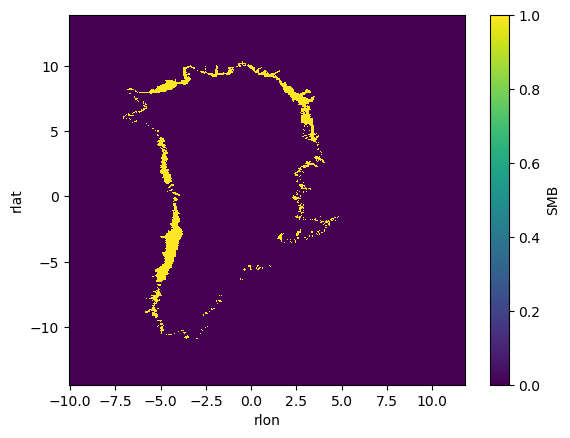

In [9]:
racmo_GrIS_ablation_mask = xr.open_dataset(home_dir+'2023-GrIS-melt-causality/data/RACMO/RACMO_ablation_mask_yearly_mean_1975_2014.nc')['SMB']
racmo_GrIS_ablation_mask = racmo_GrIS_ablation_mask.fillna(0)
racmo_lon = xr.open_dataset(home_dir+'data/RACMO/RACMO2.3p2_FGRN055/snowmelt.1958-2022.BN_RACMO2.3p2_ERA5_3h_FGRN055.MM.nc')['lon'].values #[-180, 180]
racmo_lat = xr.open_dataset(home_dir+'data/RACMO/RACMO2.3p2_FGRN055/snowmelt.1958-2022.BN_RACMO2.3p2_ERA5_3h_FGRN055.MM.nc')['lat'].values
racmo_GrIS_ablation_mask.plot();

In [13]:
racmo_data = xr.open_dataset(home_dir+'data/RACMO/RACMO2.3p2_FGRN055/BN_RACMO2.3p2_FGRN055_GrIS_precip_timmean_1979_1998.nc') #Calculated from the data in Adam's directory

regridder_racmo2f09 = xe.Regridder(racmo_data, f09_land_frac, "bilinear")
racmo2f09_GrIS_ablation_mask = regridder_racmo2f09(racmo_GrIS_ablation_mask)

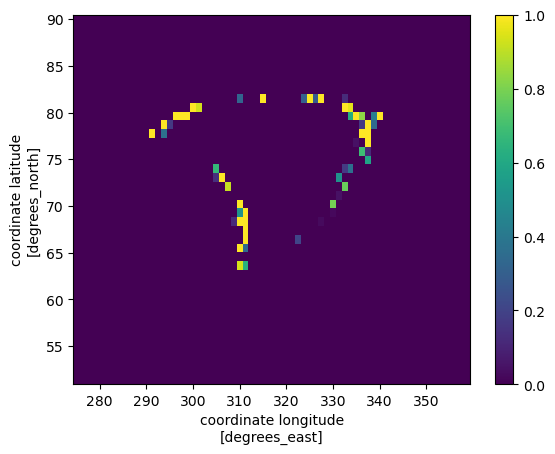

In [14]:
racmo2f09_GrIS_ablation_mask[150:,220:].plot();

## Read and calculate

In [15]:
data_dir = '/glade/campaign/cgd/cesm/CESM2-LE/timeseries/lnd/proc/tseries/month_1/'

namelist = ['1001.001', '1021.002', '1041.003', '1061.004', '1081.005', '1101.006', '1121.007', '1141.008', '1161.009', '1181.010',
            '1231.001', '1231.002', '1231.003', '1231.004', '1231.005', '1231.006', '1231.007', '1231.008', '1231.009', '1231.010',
            '1251.001', '1251.002', '1251.003', '1251.004', '1251.005', '1251.006', '1251.007', '1251.008', '1251.009', '1251.010',
            '1281.001', '1281.002', '1281.003', '1281.004', '1281.005', '1281.006', '1281.007', '1281.008', '1281.009', '1281.010',
            '1301.001', '1301.002', '1301.003', '1301.004', '1301.005', '1301.006', '1301.007', '1301.008', '1301.009', '1301.010']
#period = ['201501-202412', '202501-203412', '203501-204412', '204501-205412', '205501-206412', '206501-207412', '207501-208412', '208501-209412', '209501-210012']
period = ['205501-206412', '206501-207412', '207501-208412', '208501-209412', '209501-210012']

for index, num in enumerate(namelist):

    RAIN_monthly_list = []
    SNOW_monthly_list = []
    QICE_MELT_monthly_list = []
    QSNOMELT_monthly_list = []
    QFLX_EVAP_TOT_monthly_list = []
    QRUNOFF_monthly_list = []
    FSDS_monthly_list = []
    FSR_monthly_list = []
    FLDS_monthly_list = []
    FIRE_monthly_list = []
    FSH_monthly_list = []
    EFLX_LH_TOT_monthly_list = []
    PCT_LANDUNIT_monthly_list = []
    FSM_monthly_list = []
    FGR_monthly_list = []

    for j in period:
        RAIN_monthly_p = xr.open_dataset(data_dir+'RAIN_ICE/b.e21.BSSP370cmip6.f09_g17.LE2-'+num+'.clm2.h0.RAIN_ICE.'+j+'.nc')['RAIN_ICE'] #[mm/s]
        SNOW_monthly_p = xr.open_dataset(data_dir+'SNOW_ICE/b.e21.BSSP370cmip6.f09_g17.LE2-'+num+'.clm2.h0.SNOW_ICE.'+j+'.nc')['SNOW_ICE']
        QICE_MELT_monthly_p = xr.open_dataset(data_dir+'QICE_MELT/b.e21.BSSP370cmip6.f09_g17.LE2-'+num+'.clm2.h0.QICE_MELT.'+j+'.nc')['QICE_MELT']
        QSNOMELT_monthly_p = xr.open_dataset(data_dir+'QSNOMELT_ICE/b.e21.BSSP370cmip6.f09_g17.LE2-'+num+'.clm2.h0.QSNOMELT_ICE.'+j+'.nc')['QSNOMELT_ICE']
        QFLX_EVAP_TOT_monthly_p = xr.open_dataset(data_dir+'QFLX_EVAP_TOT/b.e21.BSSP370cmip6.f09_g17.LE2-'+num+'.clm2.h0.QFLX_EVAP_TOT.'+j+'.nc')['QFLX_EVAP_TOT']
        QRUNOFF_monthly_p = xr.open_dataset(data_dir+'QRUNOFF_ICE/b.e21.BSSP370cmip6.f09_g17.LE2-'+num+'.clm2.h0.QRUNOFF_ICE.'+j+'.nc')['QRUNOFF_ICE']
        FSDS_monthly_p = xr.open_dataset(data_dir+'FSDS/b.e21.BSSP370cmip6.f09_g17.LE2-'+num+'.clm2.h0.FSDS.'+j+'.nc')['FSDS']
        FSR_monthly_p = xr.open_dataset(data_dir+'FSR_ICE/b.e21.BSSP370cmip6.f09_g17.LE2-'+num+'.clm2.h0.FSR_ICE.'+j+'.nc')['FSR_ICE']
        FLDS_monthly_p = xr.open_dataset(data_dir+'FLDS_ICE/b.e21.BSSP370cmip6.f09_g17.LE2-'+num+'.clm2.h0.FLDS_ICE.'+j+'.nc')['FLDS_ICE']
        FIRE_monthly_p = xr.open_dataset(data_dir+'FIRE_ICE/b.e21.BSSP370cmip6.f09_g17.LE2-'+num+'.clm2.h0.FIRE_ICE.'+j+'.nc')['FIRE_ICE']
        FSH_monthly_p = xr.open_dataset(data_dir+'FSH_ICE/b.e21.BSSP370cmip6.f09_g17.LE2-'+num+'.clm2.h0.FSH_ICE.'+j+'.nc')['FSH_ICE']
        EFLX_LH_TOT_monthly_p = xr.open_dataset(data_dir+'EFLX_LH_TOT_ICE/b.e21.BSSP370cmip6.f09_g17.LE2-'+num+'.clm2.h0.EFLX_LH_TOT_ICE.'+j+'.nc')['EFLX_LH_TOT_ICE']
        PCT_LANDUNIT_monthly_p = xr.open_dataset(data_dir+'PCT_LANDUNIT/b.e21.BSSP370cmip6.f09_g17.LE2-'+num+'.clm2.h0.PCT_LANDUNIT.'+j+'.nc')['PCT_LANDUNIT'][:,3,:,:]
        FSM_monthly_p = xr.open_dataset(data_dir+'FSM/b.e21.BSSP370cmip6.f09_g17.LE2-'+num+'.clm2.h0.FSM.'+j+'.nc')['FSM']
        FGR_monthly_p = xr.open_dataset(data_dir+'FGR/b.e21.BSSP370cmip6.f09_g17.LE2-'+num+'.clm2.h0.FGR.'+j+'.nc')['FGR']

        RAIN_monthly_list.append(RAIN_monthly_p)
        SNOW_monthly_list.append(SNOW_monthly_p)
        QICE_MELT_monthly_list.append(QICE_MELT_monthly_p)
        QSNOMELT_monthly_list.append(QSNOMELT_monthly_p)
        QFLX_EVAP_TOT_monthly_list.append(QFLX_EVAP_TOT_monthly_p)
        QRUNOFF_monthly_list.append(QRUNOFF_monthly_p)
        FSDS_monthly_list.append(FSDS_monthly_p)
        FSR_monthly_list.append(FSR_monthly_p)
        FLDS_monthly_list.append(FLDS_monthly_p)
        FIRE_monthly_list.append(FIRE_monthly_p)
        FSH_monthly_list.append(FSH_monthly_p)
        EFLX_LH_TOT_monthly_list.append(EFLX_LH_TOT_monthly_p)
        PCT_LANDUNIT_monthly_list.append(PCT_LANDUNIT_monthly_p)
        FSM_monthly_list.append(FSM_monthly_p)
        FGR_monthly_list.append(FGR_monthly_p)

    RAIN_monthly = xr.concat(RAIN_monthly_list, dim='time')
    SNOW_monthly = xr.concat(SNOW_monthly_list, dim='time')
    QICE_MELT_monthly = xr.concat(QICE_MELT_monthly_list, dim='time')
    QSNOMELT_monthly = xr.concat(QSNOMELT_monthly_list, dim='time')
    QFLX_EVAP_TOT_monthly = xr.concat(QFLX_EVAP_TOT_monthly_list, dim='time')
    QRUNOFF_monthly = xr.concat(QRUNOFF_monthly_list, dim='time')
    FSDS_monthly = xr.concat(FSDS_monthly_list, dim='time')
    FSR_monthly = xr.concat(FSR_monthly_list, dim='time')
    FLDS_monthly = xr.concat(FLDS_monthly_list, dim='time')
    FIRE_monthly = xr.concat(FIRE_monthly_list, dim='time')
    FSH_monthly = xr.concat(FSH_monthly_list, dim='time')
    EFLX_LH_TOT_monthly = xr.concat(EFLX_LH_TOT_monthly_list, dim='time')
    PCT_LANDUNIT_monthly = xr.concat(PCT_LANDUNIT_monthly_list, dim='time')
    FSM_monthly = xr.concat(FSM_monthly_list, dim='time')
    FGR_monthly = xr.concat(FGR_monthly_list, dim='time')

    RAIN_monthly['time'] = dates
    SNOW_monthly['time'] = dates
    QICE_MELT_monthly['time'] = dates
    QSNOMELT_monthly['time'] = dates
    QFLX_EVAP_TOT_monthly['time'] = dates
    QRUNOFF_monthly['time'] = dates
    FSDS_monthly['time'] = dates
    FSR_monthly['time'] = dates
    FLDS_monthly['time'] = dates
    FIRE_monthly['time'] = dates
    FSH_monthly['time'] = dates
    EFLX_LH_TOT_monthly['time'] = dates
    PCT_LANDUNIT_monthly['time'] = dates
    FSM_monthly['time'] = dates
    FGR_monthly['time'] = dates

    RAIN_monthly = RAIN_monthly.sel(time=slice('2061-01-01','2100-12-31'))
    SNOW_monthly = SNOW_monthly.sel(time=slice('2061-01-01','2100-12-31'))
    QICE_MELT_monthly = QICE_MELT_monthly.sel(time=slice('2061-01-01','2100-12-31'))
    QSNOMELT_monthly = QSNOMELT_monthly.sel(time=slice('2061-01-01','2100-12-31'))
    QFLX_EVAP_TOT_monthly = QFLX_EVAP_TOT_monthly.sel(time=slice('2061-01-01','2100-12-31'))
    QRUNOFF_monthly = QRUNOFF_monthly.sel(time=slice('2061-01-01','2100-12-31'))
    FSDS_monthly = FSDS_monthly.sel(time=slice('2061-01-01','2100-12-31'))
    FSR_monthly = FSR_monthly.sel(time=slice('2061-01-01','2100-12-31'))
    FLDS_monthly = FLDS_monthly.sel(time=slice('2061-01-01','2100-12-31'))
    FIRE_monthly = FIRE_monthly.sel(time=slice('2061-01-01','2100-12-31'))
    FSH_monthly = FSH_monthly.sel(time=slice('2061-01-01','2100-12-31'))
    EFLX_LH_TOT_monthly = EFLX_LH_TOT_monthly.sel(time=slice('2061-01-01','2100-12-31'))
    PCT_LANDUNIT_monthly = PCT_LANDUNIT_monthly.sel(time=slice('2061-01-01','2100-12-31'))
    FSM_monthly = FSM_monthly.sel(time=slice('2061-01-01','2100-12-31'))
    FGR_monthly = FGR_monthly.sel(time=slice('2061-01-01','2100-12-31'))

    # GrIS ablation mask
    f09_GrIS_mask = f09_GrIS_mask0.values * racmo2f09_GrIS_ablation_mask
    f09_GrIS_mask = f09_GrIS_mask.where(f09_GrIS_mask>0)

    # Calculate
    int_QICE_MELT_monthly = (QICE_MELT_monthly * f09_GrIS_mask.values * f09_area).sum(dim=['lon','lat'])
    int_QSNOMELT_monthly = (QSNOMELT_monthly * f09_GrIS_mask.values * f09_area).sum(dim=['lon','lat'])
    int_MELT_monthly = int_QICE_MELT_monthly + int_QSNOMELT_monthly
    int_SWn_monthly = ((FSDS_monthly - FSR_monthly) * f09_GrIS_mask.values * f09_area).sum(dim=['lon','lat']) /(f09_GrIS_mask * f09_area).sum(dim=['lon','lat'])
    int_LWn_monthly = ((FLDS_monthly - FIRE_monthly) * f09_GrIS_mask.values * f09_area).sum(dim=['lon','lat']) /(f09_GrIS_mask * f09_area).sum(dim=['lon','lat'])
    int_SH_monthly = -(FSH_monthly * f09_GrIS_mask.values * f09_area).sum(dim=['lon','lat']) /(f09_GrIS_mask * f09_area).sum(dim=['lon','lat'])
    int_LH_monthly = -(EFLX_LH_TOT_monthly * f09_GrIS_mask.values * f09_area).sum(dim=['lon','lat']) /(f09_GrIS_mask * f09_area).sum(dim=['lon','lat'])
    int_GHF_monthly = -((FGR_monthly - FSM_monthly - QICE_MELT_monthly * 3.34e5) * f09_GrIS_mask.values * f09_area).sum(dim=['lon','lat']) /(f09_GrIS_mask * f09_area).sum(dim=['lon','lat'])

    Melt_dataset[index,:] = int_MELT_monthly.values *(3600*24)/1e12 #[Gt/day]
    SWn_dataset[index,:] = int_SWn_monthly.values
    LWn_dataset[index,:] = int_LWn_monthly.values
    SH_dataset[index,:] = int_SH_monthly.values
    LH_dataset[index,:] = int_LH_monthly.values
    GHF_dataset[index,:] = int_GHF_monthly.values
    print(index)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


## Save

In [16]:
time = int_SWn_monthly.time
ensemble = np.arange(1,51)

dataset = xr.Dataset(
    {
        "Melt": (("ensemble", "time"), Melt_dataset, {"units": "Gt/day"}),
        "SWn": (("ensemble", "time"), SWn_dataset, {"units": "W/m^2"}),
        "LWn": (("ensemble", "time"), LWn_dataset, {"units": "W/m^2"}),
        "SH": (("ensemble", "time"), SH_dataset, {"units": "W/m^2"}),
        "LH": (("ensemble", "time"), LH_dataset, {"units": "W/m^2"}),
        "GHF": (("ensemble", "time"), GHF_dataset, {"units": "W/m^2"}),
    },
    coords={
        "time": time,
        "ensemble": ensemble,
    }
)

In [17]:
dataset.to_netcdf("time_series_LENS2_int_Melt_SEB_RACMOablation_ICEall_monthly_2061_2100.nc")

## Data pre-processing

The next question is about stationarity. A trend and seasonal cycle can introduce non-stationary dependencies that cannot be explained causally, that is, can act as confounders. Hence, as pre-processing steps, the trend and seasonal cycle are removed by first substracting both the trend (for example, caused by greenhouse gas forcing) and the seasonal cycle and then dividing by the seasonal variance. The length scale of the Gaussian kernel used for finding the long-term trend is assumed to be decadal ($15$ years). 

Further, considering the regime behavior of the system as explained above, only the summer months June to August are considered. On a technical level, this selection of considered time periods is achieved by applying a so-called mask (also see [masking tutorial](https://github.com/jakobrunge/tigramite/blob/master/tutorials/dataset_challenges/tigramite_tutorial_missing_masking.ipynb) in tigramite).

More specifically, here the mask is such that samples for all the variables at time $t$ can only come from Jun-Aug, while samples for the times $t-1$ and $t-2$ can also come from outside this mask.

In [18]:
def process_prepare_pcmci(int_vars,
                          remove_seasonal_cycle=False,
                          add_mask=True,
                          mask_period=[5, 6, 7],
                          detrend_by_month=True,
                          divide_by_std=False,
                          smooth_width_years=15):

    # Stack arrays in sequence vertically (row wise)
    data = np.vstack((
        int_vars['Melt'].values,
        int_vars['SWn'].values,
        int_vars['LWn'].values,
        int_vars['SH'].values,
        int_vars['LH'].values,
    )).T
    T, N = data.shape

    # Variable names used throughout
    var_names = ['Melt', 'SWn', 'LWn', 'SH', 'LH']

    cycle_length = 12  # monthly data

    # ---- 1) Detrending (global OR month-wise) ----
    if detrend_by_month:
        # Month-wise detrending: smooth each calendar-month subseries separately
        smoothdata_here = np.full_like(data, np.nan, dtype=float)
        data_here       = np.full_like(data, np.nan, dtype=float)

        for m in range(cycle_length):  # m=0..11
            idx = np.arange(m, T, cycle_length)   # all samples for month m
            sub = np.copy(data[idx, :])           # (n_years, N)

            if sub.shape[0] < 3:
                # too short to smooth meaningfully
                smooth_sub = np.zeros_like(sub)
                resid_sub  = sub
            else:
                # For month-subseries sampled yearly, 15-year smoothing => smooth_width=15
                smooth_sub = pp.smooth(np.copy(sub), smooth_width=smooth_width_years,
                                       kernel='gaussian', residuals=False)
                resid_sub  = pp.smooth(np.copy(sub), smooth_width=smooth_width_years,
                                       kernel='gaussian', residuals=True)

            smoothdata_here[idx, :] = smooth_sub
            data_here[idx, :]       = resid_sub

    else:
        # Original global detrending: 15 years * 12 months
        smooth_width = smooth_width_years * cycle_length
        smoothdata_here = pp.smooth(np.copy(data), smooth_width=smooth_width,
                                    kernel='gaussian', residuals=False)
        data_here = pp.smooth(np.copy(data), smooth_width=smooth_width,
                              kernel='gaussian', residuals=True)

    # ---- 2) Remove seasonal mean and divide by seasonal standard deviation ----
    seasonal_cycle = anomalize(np.copy(data_here), cycle_length=cycle_length, return_cycle=True)
    smoothdata_here = smoothdata_here + seasonal_cycle

    if remove_seasonal_cycle:
        data_here = anomalize(data_here, cycle_length=cycle_length, divide_by_std=divide_by_std)

    # ---- 3) Construct mask (select only JJA at time t; mask_type='y') ----
    if add_mask:
        mask = np.ones(data.shape, dtype='bool')
        for i in mask_period:
            mask[i::cycle_length, :] = False
    else:
        mask = None

    # ---- 4) Tigramite DataFrame + PCMCI ----
    dataframe = pp.DataFrame(data_here, mask=mask, var_names=var_names, missing_flag=999.)

    robustparcorr = RobustParCorr(significance='analytic', mask_type='y')
    pcmci = PCMCI(
        dataframe=dataframe,
        cond_ind_test=robustparcorr,
        verbosity=0
    )

    return pcmci

## PCMCI+ causal discovery

Here, we choose ``tau_max=12`` for PCMCI. The other main parameter is ``pc_alpha`` which sets the significance level in the condition-selection step. The parameter ``alpha_level=0.05`` indicates that we threshold the resulting p-value matrix at this significance level to obtain the graph.

In the process graph, the node color denotes the auto-MCI value (the link coefficient of the lag-1 autocorrelation links) and the link colors the cross-MCI value (the link coefficients or edge weight). If links occur at multiple lags between two variables, the link color denotes the strongest one and the label lists all significant lags in order of their strength. Additionally, setting ``show_autodependency_lags=True`` will display the significant auto dependencies below the respective node labels. 

You can adjust the size and aspect ratio of nodes with `node_size` and `node_aspect` parameters, and also modify many other properties, see the parameters of `plot_graph` and `plot_time_series_graph`.

In [19]:
file = home_dir+'2023-GrIS-melt-causality/CESM2_F09/historical/LENS2/time_series_LENS2_int_Melt_SEB_RACMOablation_ICEall_monthly_2061_2100.nc'

### Aggregated graph

#### Most frequent link

##### with seasonal cycle, max_lag=12, pc_alpha=0.05

In [17]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 12  # Maximum lag for PCMCI+
pc_alpha = 0.05
remove_seasonal_cycle = False

# Initialize dictionaries to store aggregated link data by lag
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
node_autocorrelations = defaultdict(list)  # To store autocorrelations for each variable

# Loop through each ensemble member to calculate PCMCI+ results
for n in range(1, 51):  # Assuming 50 ensemble members
    # Load the nth ensemble PCMCI+ results
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('2071-01-01','2100-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=remove_seasonal_cycle, add_mask=True, mask_period=[5, 6, 7])
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    # Extract causality results
    graph = results['graph']
    val_matrix = results['val_matrix']  # Shape should be (num_vars, num_vars, max_lag + 1)

    # Loop over each pair of variables and each lag to store link types and strengths by lag
    for lag in range(0, max_lag + 1):  # Start from lag=0
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:  # Ignore self-links for this part
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    # Append link type and strength to lag-specific dictionary entries
                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Extract lag-1 autocorrelation for each variable from val_matrix diagonal
    for i, var in enumerate(variables):
        lag1_autocorrelation = val_matrix[i, i, 1]  # lag-1 autocorrelation at [i, i, 1]
        node_autocorrelations[var].append(lag1_autocorrelation)

In [18]:
# Dictionary to store the summary causal graph information for each lag
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        # Find the most common link type and its frequency
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        # Skip strength calculation if the most frequent link type is '' (no link)
        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,  # No average strength needed for no-link cases
                'frequency': freq_count
            }
        else:
            # Calculate the average strength for the most frequent link type
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])

            # Store the summarized data
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Calculate average lag-1 autocorrelation for each variable
summary_nodes = {var: np.mean(autocors) for var, autocors in node_autocorrelations.items()}

In [19]:
# Initialize 3D matrices to store the most frequent link type, colors (strength), and widths (frequency) across all lags (including lag=0)
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')  # Shape: (num_vars, num_vars, max_lag + 1)
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

# Populate link type, color, and width matrices for each lag (now including lag=0)
for lag in range(0, max_lag + 1):  # Start from lag=0
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:  # Only include actual links
            link_types[i, j, lag] = link_type  # Store the most frequent link type for this lag
            link_colors[i, j, lag] = avg_strength  # Set color based on average strength
            link_widths[i, j, lag] = frequency  # Set width based on frequency

# Prepare node colors based on average lag-1 autocorrelation
node_colors = [summary_nodes[var] for var in variables]

# Put lag-1 auto-correlation into the link matrice
for i in range(len(variables)):
    link_colors[i,i,1] = node_colors[i]
    link_types[i,i,1] = '-->'

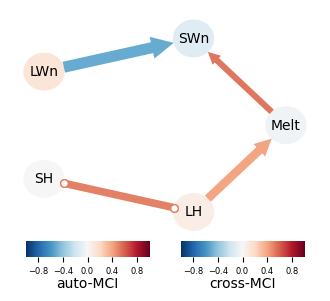

In [20]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/'
plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_seasonality_LENS2_2071_2100_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

##### with seasonal cycle, max_lag=12, pc_alpha=0.1

In [21]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 12  # Maximum lag for PCMCI+
pc_alpha = 0.1
remove_seasonal_cycle = False

# Initialize dictionaries to store aggregated link data by lag
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
node_autocorrelations = defaultdict(list)  # To store autocorrelations for each variable

# Loop through each ensemble member to calculate PCMCI+ results
for n in range(1, 51):  # Assuming 50 ensemble members
    # Load the nth ensemble PCMCI+ results
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('2071-01-01','2100-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=remove_seasonal_cycle, add_mask=True, mask_period=[5, 6, 7])
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    # Extract causality results
    graph = results['graph']
    val_matrix = results['val_matrix']  # Shape should be (num_vars, num_vars, max_lag + 1)

    # Loop over each pair of variables and each lag to store link types and strengths by lag
    for lag in range(0, max_lag + 1):  # Start from lag=0
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:  # Ignore self-links for this part
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    # Append link type and strength to lag-specific dictionary entries
                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Extract lag-1 autocorrelation for each variable from val_matrix diagonal
    for i, var in enumerate(variables):
        lag1_autocorrelation = val_matrix[i, i, 1]  # lag-1 autocorrelation at [i, i, 1]
        node_autocorrelations[var].append(lag1_autocorrelation)

In [22]:
# Dictionary to store the summary causal graph information for each lag
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        # Find the most common link type and its frequency
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        # Skip strength calculation if the most frequent link type is '' (no link)
        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,  # No average strength needed for no-link cases
                'frequency': freq_count
            }
        else:
            # Calculate the average strength for the most frequent link type
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])

            # Store the summarized data
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Calculate average lag-1 autocorrelation for each variable
summary_nodes = {var: np.mean(autocors) for var, autocors in node_autocorrelations.items()}

In [23]:
# Initialize 3D matrices to store the most frequent link type, colors (strength), and widths (frequency) across all lags (including lag=0)
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')  # Shape: (num_vars, num_vars, max_lag + 1)
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

# Populate link type, color, and width matrices for each lag (now including lag=0)
for lag in range(0, max_lag + 1):  # Start from lag=0
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:  # Only include actual links
            link_types[i, j, lag] = link_type  # Store the most frequent link type for this lag
            link_colors[i, j, lag] = avg_strength  # Set color based on average strength
            link_widths[i, j, lag] = frequency  # Set width based on frequency

# Prepare node colors based on average lag-1 autocorrelation
node_colors = [summary_nodes[var] for var in variables]

# Put lag-1 auto-correlation into the link matrice
for i in range(len(variables)):
    link_colors[i,i,1] = node_colors[i]
    link_types[i,i,1] = '-->'

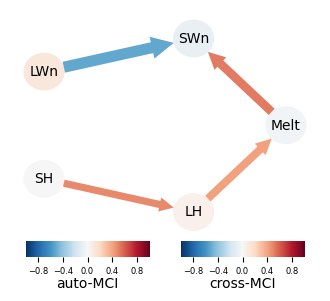

In [24]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/'
plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_seasonality_LENS2_2071_2100_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

##### with seasonal cycle, max_lag=12, pc_alpha=None

In [25]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 12  # Maximum lag for PCMCI+
pc_alpha = None
remove_seasonal_cycle = False

# Initialize dictionaries to store aggregated link data by lag
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
node_autocorrelations = defaultdict(list)  # To store autocorrelations for each variable

# Loop through each ensemble member to calculate PCMCI+ results
for n in range(1, 51):  # Assuming 50 ensemble members
    # Load the nth ensemble PCMCI+ results
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('2071-01-01','2100-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=remove_seasonal_cycle, add_mask=True, mask_period=[5, 6, 7])
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    # Extract causality results
    graph = results['graph']
    val_matrix = results['val_matrix']  # Shape should be (num_vars, num_vars, max_lag + 1)

    # Loop over each pair of variables and each lag to store link types and strengths by lag
    for lag in range(0, max_lag + 1):  # Start from lag=0
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:  # Ignore self-links for this part
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    # Append link type and strength to lag-specific dictionary entries
                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Extract lag-1 autocorrelation for each variable from val_matrix diagonal
    for i, var in enumerate(variables):
        lag1_autocorrelation = val_matrix[i, i, 1]  # lag-1 autocorrelation at [i, i, 1]
        node_autocorrelations[var].append(lag1_autocorrelation)

In [26]:
# Dictionary to store the summary causal graph information for each lag
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        # Find the most common link type and its frequency
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        # Skip strength calculation if the most frequent link type is '' (no link)
        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,  # No average strength needed for no-link cases
                'frequency': freq_count
            }
        else:
            # Calculate the average strength for the most frequent link type
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])

            # Store the summarized data
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Calculate average lag-1 autocorrelation for each variable
summary_nodes = {var: np.mean(autocors) for var, autocors in node_autocorrelations.items()}

In [27]:
# Initialize 3D matrices to store the most frequent link type, colors (strength), and widths (frequency) across all lags (including lag=0)
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')  # Shape: (num_vars, num_vars, max_lag + 1)
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

# Populate link type, color, and width matrices for each lag (now including lag=0)
for lag in range(0, max_lag + 1):  # Start from lag=0
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:  # Only include actual links
            link_types[i, j, lag] = link_type  # Store the most frequent link type for this lag
            link_colors[i, j, lag] = avg_strength  # Set color based on average strength
            link_widths[i, j, lag] = frequency  # Set width based on frequency

# Prepare node colors based on average lag-1 autocorrelation
node_colors = [summary_nodes[var] for var in variables]

# Put lag-1 auto-correlation into the link matrice
for i in range(len(variables)):
    link_colors[i,i,1] = node_colors[i]
    link_types[i,i,1] = '-->'

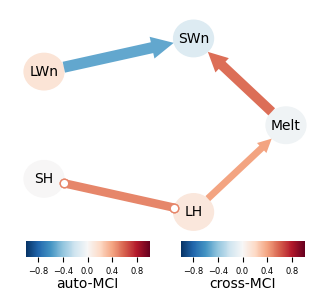

In [28]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/'
plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_seasonality_LENS2_2071_2100_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

##### without seasonal cycle, max_lag=12, pc_alpha=0.05

In [29]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 12  # Maximum lag for PCMCI+
pc_alpha = 0.05
remove_seasonal_cycle = True

# Initialize dictionaries to store aggregated link data by lag
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
node_autocorrelations = defaultdict(list)  # To store autocorrelations for each variable

# Loop through each ensemble member to calculate PCMCI+ results
for n in range(1, 51):  # Assuming 50 ensemble members
    # Load the nth ensemble PCMCI+ results
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('2071-01-01','2100-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=remove_seasonal_cycle, add_mask=True, mask_period=[5, 6, 7])
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    # Extract causality results
    graph = results['graph']
    val_matrix = results['val_matrix']  # Shape should be (num_vars, num_vars, max_lag + 1)

    # Loop over each pair of variables and each lag to store link types and strengths by lag
    for lag in range(0, max_lag + 1):  # Start from lag=0
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:  # Ignore self-links for this part
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    # Append link type and strength to lag-specific dictionary entries
                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Extract lag-1 autocorrelation for each variable from val_matrix diagonal
    for i, var in enumerate(variables):
        lag1_autocorrelation = val_matrix[i, i, 1]  # lag-1 autocorrelation at [i, i, 1]
        node_autocorrelations[var].append(lag1_autocorrelation)

In [30]:
# Dictionary to store the summary causal graph information for each lag
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        # Find the most common link type and its frequency
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        # Skip strength calculation if the most frequent link type is '' (no link)
        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,  # No average strength needed for no-link cases
                'frequency': freq_count
            }
        else:
            # Calculate the average strength for the most frequent link type
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])

            # Store the summarized data
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Calculate average lag-1 autocorrelation for each variable
summary_nodes = {var: np.mean(autocors) for var, autocors in node_autocorrelations.items()}

In [31]:
# Initialize 3D matrices to store the most frequent link type, colors (strength), and widths (frequency) across all lags (including lag=0)
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')  # Shape: (num_vars, num_vars, max_lag + 1)
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

# Populate link type, color, and width matrices for each lag (now including lag=0)
for lag in range(0, max_lag + 1):  # Start from lag=0
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:  # Only include actual links
            link_types[i, j, lag] = link_type  # Store the most frequent link type for this lag
            link_colors[i, j, lag] = avg_strength  # Set color based on average strength
            link_widths[i, j, lag] = frequency  # Set width based on frequency

# Prepare node colors based on average lag-1 autocorrelation
node_colors = [summary_nodes[var] for var in variables]

# Put lag-1 auto-correlation into the link matrice
for i in range(len(variables)):
    link_colors[i,i,1] = node_colors[i]
    link_types[i,i,1] = '-->'

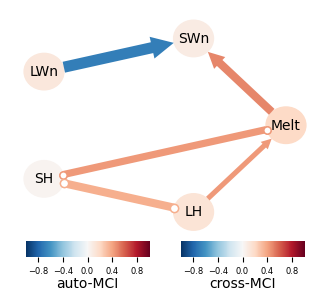

In [32]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/'
plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_noseasonality_LENS2_2071_2100_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [33]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=link_colors,
    graph=link_types,
    var_names=variables,
    link_width=link_widths,
    save_name=plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_noseasonality_LENS2_2071_2100_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'.csv',
    digits=5,
)

##### without seasonal cycle, max_lag=12, pc_alpha=0.1

In [9]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 12  # Maximum lag for PCMCI+
pc_alpha = 0.1
remove_seasonal_cycle = True

# Initialize dictionaries to store aggregated link data by lag
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
node_autocorrelations = defaultdict(list)  # To store autocorrelations for each variable

# Loop through each ensemble member to calculate PCMCI+ results
for n in range(1, 51):  # Assuming 50 ensemble members
    # Load the nth ensemble PCMCI+ results
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('2071-01-01','2100-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=remove_seasonal_cycle, add_mask=True, mask_period=[5, 6, 7])
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    # Extract causality results
    graph = results['graph']
    val_matrix = results['val_matrix']  # Shape should be (num_vars, num_vars, max_lag + 1)

    # Loop over each pair of variables and each lag to store link types and strengths by lag
    for lag in range(0, max_lag + 1):  # Start from lag=0
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:  # Ignore self-links for this part
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    # Append link type and strength to lag-specific dictionary entries
                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Extract lag-1 autocorrelation for each variable from val_matrix diagonal
    for i, var in enumerate(variables):
        lag1_autocorrelation = val_matrix[i, i, 1]  # lag-1 autocorrelation at [i, i, 1]
        node_autocorrelations[var].append(lag1_autocorrelation)

In [10]:
# Dictionary to store the summary causal graph information for each lag
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        # Find the most common link type and its frequency
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        # Skip strength calculation if the most frequent link type is '' (no link)
        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,  # No average strength needed for no-link cases
                'frequency': freq_count
            }
        else:
            # Calculate the average strength for the most frequent link type
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])

            # Store the summarized data
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Calculate average lag-1 autocorrelation for each variable
summary_nodes = {var: np.mean(autocors) for var, autocors in node_autocorrelations.items()}

In [36]:
# Initialize 3D matrices to store the most frequent link type, colors (strength), and widths (frequency) across all lags (including lag=0)
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')  # Shape: (num_vars, num_vars, max_lag + 1)
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

# Populate link type, color, and width matrices for each lag (now including lag=0)
for lag in range(0, max_lag + 1):  # Start from lag=0
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:  # Only include actual links
            link_types[i, j, lag] = link_type  # Store the most frequent link type for this lag
            link_colors[i, j, lag] = avg_strength  # Set color based on average strength
            link_widths[i, j, lag] = frequency  # Set width based on frequency

# Prepare node colors based on average lag-1 autocorrelation
node_colors = [summary_nodes[var] for var in variables]

# Put lag-1 auto-correlation into the link matrice
for i in range(len(variables)):
    link_colors[i,i,1] = node_colors[i]
    link_types[i,i,1] = '-->'

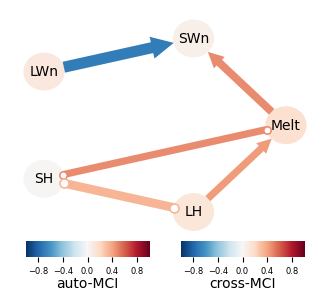

In [37]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/'
plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_noseasonality_LENS2_2071_2100_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [38]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=link_colors,
    graph=link_types,
    var_names=variables,
    link_width=link_widths,
    save_name=plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_noseasonality_LENS2_2071_2100_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'.csv',
    digits=5,
)

In [11]:
plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/2071_2100/'
save_name = plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_noseasonality_LENS2_2071_2100_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'.csv'
pd.read_csv(save_name)

,Variable i,Variable j,Time lag of i,Link type i --- j,Link value,Link width
0,Melt,Melt,1,-->,0.162400,0.0
1,Melt,SWn,0,-->,0.470830,24.0
2,Melt,SH,0,o-o,0.475270,22.0
3,Melt,LH,0,<--,0.423940,22.0
4,SWn,SWn,1,-->,0.060775,0.0
5,SWn,LWn,0,<--,-0.698770,34.0
6,LWn,LWn,1,-->,0.108830,0.0
7,SH,SH,1,-->,0.012473,0.0
8,SH,LH,0,o-o,0.342120,27.0
9,LH,LH,1,-->,0.121160,0.0


##### without seasonal cycle, max_lag=12, pc_alpha=None

In [39]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 12  # Maximum lag for PCMCI+
pc_alpha = None
remove_seasonal_cycle = True

# Initialize dictionaries to store aggregated link data by lag
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
node_autocorrelations = defaultdict(list)  # To store autocorrelations for each variable

# Loop through each ensemble member to calculate PCMCI+ results
for n in range(1, 51):  # Assuming 50 ensemble members
    # Load the nth ensemble PCMCI+ results
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('2071-01-01','2100-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=remove_seasonal_cycle, add_mask=True, mask_period=[5, 6, 7])
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    # Extract causality results
    graph = results['graph']
    val_matrix = results['val_matrix']  # Shape should be (num_vars, num_vars, max_lag + 1)

    # Loop over each pair of variables and each lag to store link types and strengths by lag
    for lag in range(0, max_lag + 1):  # Start from lag=0
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:  # Ignore self-links for this part
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    # Append link type and strength to lag-specific dictionary entries
                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Extract lag-1 autocorrelation for each variable from val_matrix diagonal
    for i, var in enumerate(variables):
        lag1_autocorrelation = val_matrix[i, i, 1]  # lag-1 autocorrelation at [i, i, 1]
        node_autocorrelations[var].append(lag1_autocorrelation)

In [40]:
# Dictionary to store the summary causal graph information for each lag
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        # Find the most common link type and its frequency
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        # Skip strength calculation if the most frequent link type is '' (no link)
        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,  # No average strength needed for no-link cases
                'frequency': freq_count
            }
        else:
            # Calculate the average strength for the most frequent link type
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])

            # Store the summarized data
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Calculate average lag-1 autocorrelation for each variable
summary_nodes = {var: np.mean(autocors) for var, autocors in node_autocorrelations.items()}

In [41]:
# Initialize 3D matrices to store the most frequent link type, colors (strength), and widths (frequency) across all lags (including lag=0)
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')  # Shape: (num_vars, num_vars, max_lag + 1)
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

# Populate link type, color, and width matrices for each lag (now including lag=0)
for lag in range(0, max_lag + 1):  # Start from lag=0
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:  # Only include actual links
            link_types[i, j, lag] = link_type  # Store the most frequent link type for this lag
            link_colors[i, j, lag] = avg_strength  # Set color based on average strength
            link_widths[i, j, lag] = frequency  # Set width based on frequency

# Prepare node colors based on average lag-1 autocorrelation
node_colors = [summary_nodes[var] for var in variables]

# Put lag-1 auto-correlation into the link matrice
for i in range(len(variables)):
    link_colors[i,i,1] = node_colors[i]
    link_types[i,i,1] = '-->'

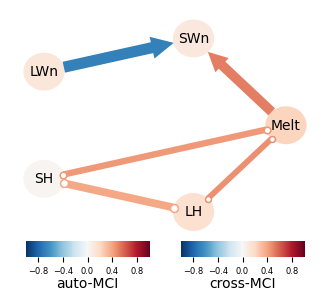

In [42]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/'
plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_noseasonality_LENS2_2071_2100_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [43]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=link_colors,
    graph=link_types,
    var_names=variables,
    link_width=link_widths,
    save_name=plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_noseasonality_LENS2_2071_2100_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'.csv',
    digits=5,
)

##### without seasonal cycle, max_lag=3, pc_alpha=0.1

In [44]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 3  # Maximum lag for PCMCI+
pc_alpha = 0.1
remove_seasonal_cycle = True

# Initialize dictionaries to store aggregated link data by lag
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
node_autocorrelations = defaultdict(list)  # To store autocorrelations for each variable

# Loop through each ensemble member to calculate PCMCI+ results
for n in range(1, 51):  # Assuming 50 ensemble members
    # Load the nth ensemble PCMCI+ results
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('2071-01-01','2100-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=remove_seasonal_cycle, add_mask=True, mask_period=[5, 6, 7])
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    # Extract causality results
    graph = results['graph']
    val_matrix = results['val_matrix']  # Shape should be (num_vars, num_vars, max_lag + 1)

    # Loop over each pair of variables and each lag to store link types and strengths by lag
    for lag in range(0, max_lag + 1):  # Start from lag=0
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:  # Ignore self-links for this part
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    # Append link type and strength to lag-specific dictionary entries
                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Extract lag-1 autocorrelation for each variable from val_matrix diagonal
    for i, var in enumerate(variables):
        lag1_autocorrelation = val_matrix[i, i, 1]  # lag-1 autocorrelation at [i, i, 1]
        node_autocorrelations[var].append(lag1_autocorrelation)

In [45]:
# Dictionary to store the summary causal graph information for each lag
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        # Find the most common link type and its frequency
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        # Skip strength calculation if the most frequent link type is '' (no link)
        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,  # No average strength needed for no-link cases
                'frequency': freq_count
            }
        else:
            # Calculate the average strength for the most frequent link type
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])

            # Store the summarized data
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Calculate average lag-1 autocorrelation for each variable
summary_nodes = {var: np.mean(autocors) for var, autocors in node_autocorrelations.items()}

In [46]:
# Initialize 3D matrices to store the most frequent link type, colors (strength), and widths (frequency) across all lags (including lag=0)
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')  # Shape: (num_vars, num_vars, max_lag + 1)
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

# Populate link type, color, and width matrices for each lag (now including lag=0)
for lag in range(0, max_lag + 1):  # Start from lag=0
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:  # Only include actual links
            link_types[i, j, lag] = link_type  # Store the most frequent link type for this lag
            link_colors[i, j, lag] = avg_strength  # Set color based on average strength
            link_widths[i, j, lag] = frequency  # Set width based on frequency

# Prepare node colors based on average lag-1 autocorrelation
node_colors = [summary_nodes[var] for var in variables]

# Put lag-1 auto-correlation into the link matrice
for i in range(len(variables)):
    link_colors[i,i,1] = node_colors[i]
    link_types[i,i,1] = '-->'

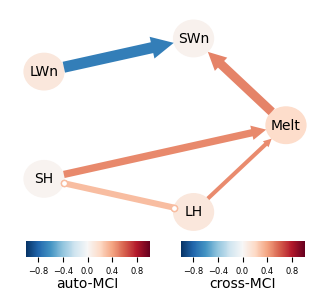

In [47]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/'
plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_noseasonality_LENS2_2071_2100_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

##### without seasonal cycle, max_lag=6, pc_alpha=None

In [48]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 6  # Maximum lag for PCMCI+
pc_alpha = None
remove_seasonal_cycle = True

# Initialize dictionaries to store aggregated link data by lag
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
node_autocorrelations = defaultdict(list)  # To store autocorrelations for each variable

# Loop through each ensemble member to calculate PCMCI+ results
for n in range(1, 51):  # Assuming 50 ensemble members
    # Load the nth ensemble PCMCI+ results
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('2071-01-01','2100-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=remove_seasonal_cycle, add_mask=True, mask_period=[5, 6, 7])
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    # Extract causality results
    graph = results['graph']
    val_matrix = results['val_matrix']  # Shape should be (num_vars, num_vars, max_lag + 1)

    # Loop over each pair of variables and each lag to store link types and strengths by lag
    for lag in range(0, max_lag + 1):  # Start from lag=0
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:  # Ignore self-links for this part
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    # Append link type and strength to lag-specific dictionary entries
                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Extract lag-1 autocorrelation for each variable from val_matrix diagonal
    for i, var in enumerate(variables):
        lag1_autocorrelation = val_matrix[i, i, 1]  # lag-1 autocorrelation at [i, i, 1]
        node_autocorrelations[var].append(lag1_autocorrelation)

In [49]:
# Dictionary to store the summary causal graph information for each lag
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        # Find the most common link type and its frequency
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        # Skip strength calculation if the most frequent link type is '' (no link)
        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,  # No average strength needed for no-link cases
                'frequency': freq_count
            }
        else:
            # Calculate the average strength for the most frequent link type
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])

            # Store the summarized data
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Calculate average lag-1 autocorrelation for each variable
summary_nodes = {var: np.mean(autocors) for var, autocors in node_autocorrelations.items()}

In [50]:
# Initialize 3D matrices to store the most frequent link type, colors (strength), and widths (frequency) across all lags (including lag=0)
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')  # Shape: (num_vars, num_vars, max_lag + 1)
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

# Populate link type, color, and width matrices for each lag (now including lag=0)
for lag in range(0, max_lag + 1):  # Start from lag=0
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:  # Only include actual links
            link_types[i, j, lag] = link_type  # Store the most frequent link type for this lag
            link_colors[i, j, lag] = avg_strength  # Set color based on average strength
            link_widths[i, j, lag] = frequency  # Set width based on frequency

# Prepare node colors based on average lag-1 autocorrelation
node_colors = [summary_nodes[var] for var in variables]

# Put lag-1 auto-correlation into the link matrice
for i in range(len(variables)):
    link_colors[i,i,1] = node_colors[i]
    link_types[i,i,1] = '-->'

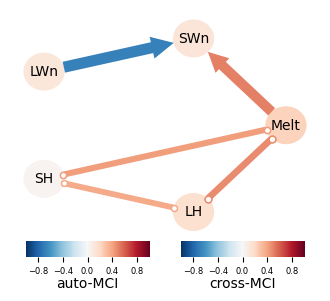

In [51]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/'
plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_noseasonality_LENS2_2071_2100_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

##### without seasonal cycle, max_lag=15, pc_alpha=None

In [52]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 15  # Maximum lag for PCMCI+
pc_alpha = None
remove_seasonal_cycle = True

# Initialize dictionaries to store aggregated link data by lag
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
node_autocorrelations = defaultdict(list)  # To store autocorrelations for each variable

# Loop through each ensemble member to calculate PCMCI+ results
for n in range(1, 51):  # Assuming 50 ensemble members
    # Load the nth ensemble PCMCI+ results
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('2071-01-01','2100-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=remove_seasonal_cycle, add_mask=True, mask_period=[5, 6, 7])
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    # Extract causality results
    graph = results['graph']
    val_matrix = results['val_matrix']  # Shape should be (num_vars, num_vars, max_lag + 1)

    # Loop over each pair of variables and each lag to store link types and strengths by lag
    for lag in range(0, max_lag + 1):  # Start from lag=0
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:  # Ignore self-links for this part
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    # Append link type and strength to lag-specific dictionary entries
                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Extract lag-1 autocorrelation for each variable from val_matrix diagonal
    for i, var in enumerate(variables):
        lag1_autocorrelation = val_matrix[i, i, 1]  # lag-1 autocorrelation at [i, i, 1]
        node_autocorrelations[var].append(lag1_autocorrelation)

In [53]:
# Dictionary to store the summary causal graph information for each lag
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        # Find the most common link type and its frequency
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        # Skip strength calculation if the most frequent link type is '' (no link)
        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,  # No average strength needed for no-link cases
                'frequency': freq_count
            }
        else:
            # Calculate the average strength for the most frequent link type
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])

            # Store the summarized data
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Calculate average lag-1 autocorrelation for each variable
summary_nodes = {var: np.mean(autocors) for var, autocors in node_autocorrelations.items()}

In [54]:
# Initialize 3D matrices to store the most frequent link type, colors (strength), and widths (frequency) across all lags (including lag=0)
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')  # Shape: (num_vars, num_vars, max_lag + 1)
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

# Populate link type, color, and width matrices for each lag (now including lag=0)
for lag in range(0, max_lag + 1):  # Start from lag=0
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:  # Only include actual links
            link_types[i, j, lag] = link_type  # Store the most frequent link type for this lag
            link_colors[i, j, lag] = avg_strength  # Set color based on average strength
            link_widths[i, j, lag] = frequency  # Set width based on frequency

# Prepare node colors based on average lag-1 autocorrelation
node_colors = [summary_nodes[var] for var in variables]

# Put lag-1 auto-correlation into the link matrice
for i in range(len(variables)):
    link_colors[i,i,1] = node_colors[i]
    link_types[i,i,1] = '-->'

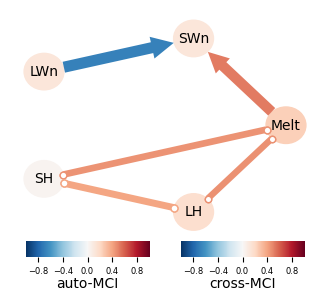

In [55]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/'
plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_noseasonality_LENS2_2071_2100_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

### Aggregated graph, divided by std (corrected for significance of self-MCI)

##### without seasonal cycle, max_lag=12, pc_alpha=0.025

In [63]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 12
pc_alpha = 0.025
remove_seasonal_cycle = True
detrend_by_month = True
divide_by_std = True
smooth_width_years = 15

# Initialize storage
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}

# For auto-MCI: store max self-MCI value and significance across ensemble members
node_self_mci_values = defaultdict(list)       # Max auto-MCI values
node_self_mci_significance = defaultdict(list) # Whether max auto-MCI is significant

for n in range(1, 51):  # Loop over 50 ensemble members
    # Load and prepare data
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('2061-01-01','2100-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=remove_seasonal_cycle, add_mask=True, mask_period=[5, 6, 7], detrend_by_month=detrend_by_month, divide_by_std=divide_by_std, smooth_width_years=smooth_width_years)
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    graph = results['graph']
    val_matrix = results['val_matrix']

    # Collect cross-links
    for lag in range(0, max_lag + 1):
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Compute max auto-MCI (across all lags ≥1) and check significance
    for i, var in enumerate(variables):
        # Extract all self-lag values
        self_vals = val_matrix[i, i, 1:]
        max_val = np.max(np.abs(self_vals))   # Max magnitude auto-MCI
        max_lag_idx = np.argmax(np.abs(self_vals)) + 1  # Which lag

        # Check significance: is there a self-link at that lag in the graph?
        is_significant = graph[i, i, max_lag_idx] != '' and graph[i, i, max_lag_idx] != 'o-o'

        node_self_mci_values[var].append(max_val)
        node_self_mci_significance[var].append(is_significant)

In [64]:
# Summarize cross-links as before
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,
                'frequency': freq_count
            }
        else:
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Compute node colors: average max auto-MCI, but set to 0 if not significant in majority of members
summary_nodes = {}
for var in variables:
    # Fraction of members where max auto-MCI is significant
    sig_fraction = np.mean(node_self_mci_significance[var])

    if sig_fraction > 0.5:  # majority significant
        summary_nodes[var] = np.mean(node_self_mci_values[var])
    else:
        summary_nodes[var] = 0.0

In [65]:
# Prepare matrices for cross-links
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

for lag in range(0, max_lag + 1):
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:
            link_types[i, j, lag] = link_type
            link_colors[i, j, lag] = avg_strength
            link_widths[i, j, lag] = frequency

# Node colors: summary_nodes already considers significance
node_colors = [summary_nodes[var] for var in variables]

# Assign node colors to self-link at lag 1 (for plotting)
for i in range(num_vars):
    link_colors[i, i, 1] = node_colors[i]
    link_types[i, i, 1] = '-->'

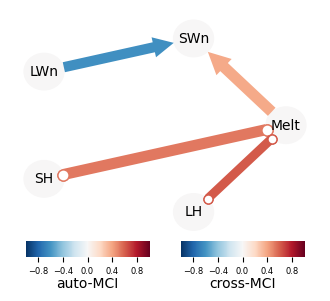

In [66]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/2061_2100/ICE/'
plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2061_2100_conservative_nofdrc_robustparcorr_rmmontrend_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [67]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=link_colors,
    graph=link_types,
    var_names=variables,
    link_width=link_widths,
    save_name=home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2061_2100_conservative_nofdrc_robustparcorr_rmmontrend_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.csv',
    digits=5,
)

In [68]:
save_name = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2061_2100_conservative_nofdrc_robustparcorr_rmmontrend_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.csv'
pd.read_csv(save_name)

,Variable i,Variable j,Time lag of i,Link type i --- j,Link value,Link width
0,Melt,Melt,1,-->,0.00000,0.0
1,Melt,SWn,0,-->,0.38256,37.0
2,Melt,SH,0,o-o,0.52695,37.0
3,Melt,LH,0,o-o,0.61001,30.0
4,SWn,SWn,1,-->,0.00000,0.0
5,SWn,LWn,0,<--,-0.61033,34.0
6,LWn,LWn,1,-->,0.00000,0.0
7,SH,SH,1,-->,0.00000,0.0
8,LH,LH,1,-->,0.00000,0.0


In [69]:
# Save for plotting (since the format saved by tp.write_csv is hard to use)
save_name = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2061_2100_conservative_nofdrc_robustparcorr_rmmontrend_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig_forplot.npz'

np.savez(save_name,
         val_matrix=link_colors,
         graph=link_types,
         link_width=link_widths,
         var_names=np.array(variables))

##### without seasonal cycle, max_lag=12, pc_alpha=0.05

In [20]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 12
pc_alpha = 0.05
remove_seasonal_cycle = True
detrend_by_month = True
divide_by_std = True
smooth_width_years = 15

# Initialize storage
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}

# For auto-MCI: store max self-MCI value and significance across ensemble members
node_self_mci_values = defaultdict(list)       # Max auto-MCI values
node_self_mci_significance = defaultdict(list) # Whether max auto-MCI is significant

for n in range(1, 51):  # Loop over 50 ensemble members
    # Load and prepare data
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('2061-01-01','2100-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=remove_seasonal_cycle, add_mask=True, mask_period=[5, 6, 7], detrend_by_month=detrend_by_month, divide_by_std=divide_by_std, smooth_width_years=smooth_width_years)
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    graph = results['graph']
    val_matrix = results['val_matrix']

    # Collect cross-links
    for lag in range(0, max_lag + 1):
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Compute max auto-MCI (across all lags ≥1) and check significance
    for i, var in enumerate(variables):
        # Extract all self-lag values
        self_vals = val_matrix[i, i, 1:]
        max_val = np.max(np.abs(self_vals))   # Max magnitude auto-MCI
        max_lag_idx = np.argmax(np.abs(self_vals)) + 1  # Which lag

        # Check significance: is there a self-link at that lag in the graph?
        is_significant = graph[i, i, max_lag_idx] != '' and graph[i, i, max_lag_idx] != 'o-o'

        node_self_mci_values[var].append(max_val)
        node_self_mci_significance[var].append(is_significant)

In [21]:
# Summarize cross-links as before
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,
                'frequency': freq_count
            }
        else:
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Compute node colors: average max auto-MCI, but set to 0 if not significant in majority of members
summary_nodes = {}
for var in variables:
    # Fraction of members where max auto-MCI is significant
    sig_fraction = np.mean(node_self_mci_significance[var])

    if sig_fraction > 0.5:  # majority significant
        summary_nodes[var] = np.mean(node_self_mci_values[var])
    else:
        summary_nodes[var] = 0.0

In [22]:
# Prepare matrices for cross-links
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

for lag in range(0, max_lag + 1):
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:
            link_types[i, j, lag] = link_type
            link_colors[i, j, lag] = avg_strength
            link_widths[i, j, lag] = frequency

# Node colors: summary_nodes already considers significance
node_colors = [summary_nodes[var] for var in variables]

# Assign node colors to self-link at lag 1 (for plotting)
for i in range(num_vars):
    link_colors[i, i, 1] = node_colors[i]
    link_types[i, i, 1] = '-->'

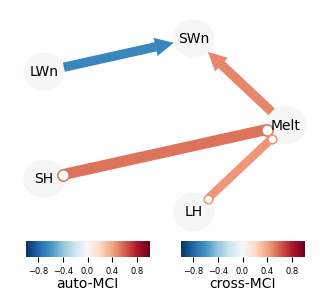

In [23]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/2061_2100/ICE/'
plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_RACMOablation_ICEall_noseasonality_LENS2_2061_2100_conservative_nofdrc_robustparcorr_rmmontrend_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [24]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=link_colors,
    graph=link_types,
    var_names=variables,
    link_width=link_widths,
    save_name=home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_RACMOablation_ICEall_noseasonality_LENS2_2061_2100_conservative_nofdrc_robustparcorr_rmmontrend_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.csv',
    digits=5,
)

In [25]:
save_name = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_RACMOablation_ICEall_noseasonality_LENS2_2061_2100_conservative_nofdrc_robustparcorr_rmmontrend_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.csv'
pd.read_csv(save_name)

,Variable i,Variable j,Time lag of i,Link type i --- j,Link value,Link width
0,Melt,Melt,1,-->,0.00000,0.0
1,Melt,SWn,0,-->,0.49083,31.0
2,Melt,SH,0,o-o,0.54252,37.0
3,Melt,LH,0,o-o,0.44497,28.0
4,SWn,SWn,1,-->,0.00000,0.0
5,SWn,LWn,0,<--,-0.64929,31.0
6,LWn,LWn,1,-->,0.00000,0.0
7,SH,SH,1,-->,0.00000,0.0
8,LH,LH,1,-->,0.00000,0.0


In [26]:
# Save for plotting (since the format saved by tp.write_csv is hard to use)
save_name = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_RACMOablation_ICEall_noseasonality_LENS2_2061_2100_conservative_nofdrc_robustparcorr_rmmontrend_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig_forplot.npz'

np.savez(save_name,
         val_matrix=link_colors,
         graph=link_types,
         link_width=link_widths,
         var_names=np.array(variables))

##### without seasonal cycle, max_lag=12, pc_alpha=0.1

In [77]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 12
pc_alpha = 0.1
remove_seasonal_cycle = True
detrend_by_month = True
divide_by_std = True
smooth_width_years = 15

# Initialize storage
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}

# For auto-MCI: store max self-MCI value and significance across ensemble members
node_self_mci_values = defaultdict(list)       # Max auto-MCI values
node_self_mci_significance = defaultdict(list) # Whether max auto-MCI is significant

for n in range(1, 51):  # Loop over 50 ensemble members
    # Load and prepare data
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('2061-01-01','2100-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=remove_seasonal_cycle, add_mask=True, mask_period=[5, 6, 7], detrend_by_month=detrend_by_month, divide_by_std=divide_by_std, smooth_width_years=smooth_width_years)
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    graph = results['graph']
    val_matrix = results['val_matrix']

    # Collect cross-links
    for lag in range(0, max_lag + 1):
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Compute max auto-MCI (across all lags ≥1) and check significance
    for i, var in enumerate(variables):
        # Extract all self-lag values
        self_vals = val_matrix[i, i, 1:]
        max_val = np.max(np.abs(self_vals))   # Max magnitude auto-MCI
        max_lag_idx = np.argmax(np.abs(self_vals)) + 1  # Which lag

        # Check significance: is there a self-link at that lag in the graph?
        is_significant = graph[i, i, max_lag_idx] != '' and graph[i, i, max_lag_idx] != 'o-o'

        node_self_mci_values[var].append(max_val)
        node_self_mci_significance[var].append(is_significant)

In [78]:
# Summarize cross-links as before
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,
                'frequency': freq_count
            }
        else:
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Compute node colors: average max auto-MCI, but set to 0 if not significant in majority of members
summary_nodes = {}
for var in variables:
    # Fraction of members where max auto-MCI is significant
    sig_fraction = np.mean(node_self_mci_significance[var])

    if sig_fraction > 0.5:  # majority significant
        summary_nodes[var] = np.mean(node_self_mci_values[var])
    else:
        summary_nodes[var] = 0.0

In [79]:
# Prepare matrices for cross-links
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

for lag in range(0, max_lag + 1):
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:
            link_types[i, j, lag] = link_type
            link_colors[i, j, lag] = avg_strength
            link_widths[i, j, lag] = frequency

# Node colors: summary_nodes already considers significance
node_colors = [summary_nodes[var] for var in variables]

# Assign node colors to self-link at lag 1 (for plotting)
for i in range(num_vars):
    link_colors[i, i, 1] = node_colors[i]
    link_types[i, i, 1] = '-->'

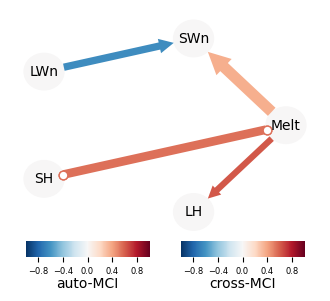

In [80]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/2061_2100/ICE/'
plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2061_2100_conservative_nofdrc_robustparcorr_rmmontrend_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [81]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=link_colors,
    graph=link_types,
    var_names=variables,
    link_width=link_widths,
    save_name=home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2061_2100_conservative_nofdrc_robustparcorr_rmmontrend_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.csv',
    digits=5,
)

In [82]:
save_name = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2061_2100_conservative_nofdrc_robustparcorr_rmmontrend_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.csv'
pd.read_csv(save_name)

,Variable i,Variable j,Time lag of i,Link type i --- j,Link value,Link width
0,Melt,Melt,1,-->,0.00000,0.0
1,Melt,SWn,0,-->,0.36055,41.0
2,Melt,SH,0,o-o,0.55406,32.0
3,Melt,LH,0,-->,0.61985,23.0
4,SWn,SWn,1,-->,0.00000,0.0
5,SWn,LWn,0,<--,-0.62596,27.0
6,LWn,LWn,1,-->,0.00000,0.0
7,SH,SH,1,-->,0.00000,0.0
8,LH,LH,1,-->,0.00000,0.0


In [83]:
# Save for plotting (since the format saved by tp.write_csv is hard to use)
save_name = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2061_2100_conservative_nofdrc_robustparcorr_rmmontrend_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig_forplot.npz'

np.savez(save_name,
         val_matrix=link_colors,
         graph=link_types,
         link_width=link_widths,
         var_names=np.array(variables))

In [13]:
# ===== Save contemporaneous strengths (lag=0) regardless of direction =====
pairs = [('SWn', 'Melt'), ('SH', 'Melt'), ('LH', 'Melt')]
var_to_idx = {v: i for i, v in enumerate(variables)}

lag0 = 0
valid_types = {'-->', '<--', 'o-o', 'x-x'}   # anything not '' counts as a detected contemporaneous link

# Infer number of members from any stored list at lag 0
# (fall back to 50 if unavailable, but your lists should have length 50)
_sample_key = next(iter(link_types_by_lag[lag0]))
n_members = len(link_types_by_lag[lag0][_sample_key]) if link_types_by_lag[lag0] else 50

out = {}

for a, b in pairs:
    i, j = var_to_idx[a], var_to_idx[b]

    # Get lists across members; guard if a key is missing
    types_ij   = link_types_by_lag[lag0].get((i, j),   [''] * n_members)
    types_ji   = link_types_by_lag[lag0].get((j, i),   [''] * n_members)
    streng_ij  = link_strengths_by_lag[lag0].get((i, j), [np.nan] * n_members)
    streng_ji  = link_strengths_by_lag[lag0].get((j, i), [np.nan] * n_members)

    sym_strength = np.full(n_members, np.nan, dtype=float)

    for k in range(n_members):
        s_list = []
        if types_ij[k] in valid_types and np.isfinite(streng_ij[k]):
            s_list.append(streng_ij[k])
        if types_ji[k] in valid_types and np.isfinite(streng_ji[k]):
            s_list.append(streng_ji[k])

        # mean absolute strength across whatever directions were detected this member
        if s_list:
            sym_strength[k] = float(np.mean(s_list))  # could use max(s_list) if you prefer

    out[f'{a}_to_{b}_lag0_anydir'] = sym_strength

# (Optional) also save direction tallies per member for auditing
dir_counts = {}
for a, b in pairs:
    i, j = var_to_idx[a], var_to_idx[b]
    types_ij = link_types_by_lag[lag0].get((i, j), [''] * n_members)
    types_ji = link_types_by_lag[lag0].get((j, i), [''] * n_members)
    dir_counts[f'{a}_{b}_dir_ij'] = np.array(types_ij, dtype='U3')
    dir_counts[f'{a}_{b}_dir_ji'] = np.array(types_ji, dtype='U3')

save_path = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/lens2_2071_2100_contemp_strengths_anydir_SWn_SH_LH_Melt_lag0.npz'
np.savez(
    save_path,
    **out,
    **dir_counts,
    meta=np.array([
        "Definition: per-member mean |cross-MCI| at lag=0 across any detected direction "
        "(i→j and/or j→i); NaN = no contemporaneous link detected in either direction.",
        f"variables: {variables}",
        f"pc_alpha={pc_alpha}, remove_seasonal_cycle={remove_seasonal_cycle}, mask=JJA"
    ], dtype=object),
)
print(f"Saved contemporaneous strengths (any direction) to: {save_path}")

Saved contemporaneous strengths (any direction) to: /glade/work/ziqiyin/2023-GrIS-melt-causality/data/LENS2/ICE/lens2_2071_2100_contemp_strengths_anydir_SWn_SH_LH_Melt_lag0.npz


In [14]:
# Read in and plot
data = np.load(save_path, allow_pickle=True)

SWn_strength = data['SWn_to_Melt_lag0_anydir']
SH_strength  = data['SH_to_Melt_lag0_anydir']
LH_strength  = data['LH_to_Melt_lag0_anydir']

print("SWn-Melt strengths:", SWn_strength)
print("Mean:", np.nanmean(SWn_strength))
print("Number of valid detections:", np.sum(~np.isnan(SWn_strength)))
print("")
print("SH-Melt strengths:", SH_strength)
print("Mean:", np.nanmean(SH_strength))
print("Number of valid detections:", np.sum(~np.isnan(SH_strength)))
print("")
print("LH-Melt strengths:", LH_strength)
print("Mean:", np.nanmean(LH_strength))
print("Number of valid detections:", np.sum(~np.isnan(LH_strength)))

SWn-Melt strengths: [0.32155197 0.28265793 0.37032562 0.38247561 0.31375141 0.42958276
 0.39272342 0.35028681 0.25531738 0.25821962 0.46347625 0.70807606
 0.30629568 0.36522548 0.39807807 0.37275485 0.24453214 0.29481426
 0.56177981 0.26294576 0.24124434 0.61158352 0.24046752        nan
 0.40914725 0.31050179 0.57783031 0.38546354 0.23493858 0.26960991
 0.51692114 0.37196645 0.47498946 0.32169499 0.58889377 0.58393331
 0.32997144 0.45844703 0.19636831 0.2911998  0.38642637 0.31973802
 0.33043141 0.2043404  0.41566398 0.24162738 0.28506919 0.33213835
        nan 0.63297566]
Mean: 0.37288446032093553
Number of valid detections: 48

SH-Melt strengths: [0.40931357 0.26087719 0.56893933 0.50412911 0.39299719 0.59309236
 0.64385174 0.43894142 0.59637804 0.75371393 0.52722039 0.58329578
 0.46035301 0.49657046 0.46668939 0.4842625  0.44576009 0.53160194
 0.3558332  0.45540256 0.70700851 0.53044989 0.46559295 0.74003116
 0.55081637 0.29529321 0.57352268 0.37369498 0.39697034 0.68211375
 0.25092

In [84]:
# ===== Save contemporaneous strengths (lag=0) for the most-frequent link type =====
pairs = [('SWn', 'Melt'), ('SH', 'Melt'), ('LH', 'Melt')]
var_to_idx = {v: i for i, v in enumerate(variables)}

lag0 = 0
valid_types = {'-->', '<--', 'o-o', 'x-x'}  # contemporaneous link encodings

# Infer number of members
_sample_key = next(iter(link_types_by_lag[lag0]))
n_members = len(link_types_by_lag[lag0][_sample_key]) if link_types_by_lag[lag0] else 50

def consolidate_type(t_ij, t_ji):
    """Pick a single contemporaneous type for this member between vars i and j."""
    # Prefer explicit types; if both present but mismatch, pick a stable rule:
    # If either is undirected, treat as undirected; else prefer '-->' or '<--' if present.
    if t_ij in valid_types and t_ji in valid_types:
        if ('o-o' in (t_ij, t_ji)) or ('x-x' in (t_ij, t_ji)):
            return 'o-o' if 'o-o' in (t_ij, t_ji) else 'x-x'
        # If both are directed but inconsistent, prefer t_ij (stable, deterministic)
        return t_ij
    if t_ij in valid_types:
        return t_ij
    if t_ji in valid_types:
        # Map the (j,i) direction into the canonical i–j viewpoint:
        # If (j,i) shows '-->' that means j→i, i.e., '<--' for (i,j)
        if t_ji == '-->':
            return '<--'
        if t_ji == '<--':
            return '-->'
        return t_ji  # 'o-o' or 'x-x'
    return ''  # no contemporaneous link detected

# Priority for final tie-break if needed
type_priority = ['-->', '<--', 'o-o', 'x-x']

out = {}
dir_counts = {}
mf_type_meta = {}
mf_type_counts = {}
mf_type_mean_strength = {}

for a, b in pairs:
    i, j = var_to_idx[a], var_to_idx[b]

    types_ij  = link_types_by_lag[lag0].get((i, j),   [''] * n_members)
    types_ji  = link_types_by_lag[lag0].get((j, i),   [''] * n_members)
    streng_ij = link_strengths_by_lag[lag0].get((i, j), [np.nan] * n_members)
    streng_ji = link_strengths_by_lag[lag0].get((j, i), [np.nan] * n_members)

    # Per-member consolidated type (one of '-->','<--','o-o','x-x','')
    cons_types = np.array(
        [consolidate_type(types_ij[k], types_ji[k]) for k in range(n_members)],
        dtype='U3'
    )

    # Count frequencies among *detected* types (exclude '')
    counts = {t: int(np.sum(cons_types == t)) for t in valid_types}

    # If no detections at all, keep all-NaN and record 'none'
    if sum(counts.values()) == 0:
        out[f'{a}_to_{b}_lag0_mostfreq'] = np.full(n_members, np.nan, dtype=float)
        mf_type_meta[f'{a}_{b}_mostfreq_type'] = 'none'
        mf_type_counts[f'{a}_{b}_counts'] = counts
        mf_type_mean_strength[f'{a}_{b}_type_means'] = {t: np.nan for t in valid_types}
        # Keep auditing arrays
        dir_counts[f'{a}_{b}_dir_ij'] = np.array(types_ij, dtype='U3')
        dir_counts[f'{a}_{b}_dir_ji'] = np.array(types_ji, dtype='U3')
        continue

    # Candidate types with max count
    max_count = max(counts.values())
    tied = [t for t, c in counts.items() if c == max_count and c > 0]

    # For tie-break: compute mean |strength| across members that *have that type*
    def member_strength_for_type(k, t):
        if t == '-->':  # i -> j
            return streng_ij[k] if np.isfinite(streng_ij[k]) else np.nan
        if t == '<--':  # j -> i
            return streng_ji[k] if np.isfinite(streng_ji[k]) else np.nan
        if t in ('o-o', 'x-x'):
            # mean of available directions (your prior choice)
            vals = []
            if np.isfinite(streng_ij[k]): vals.append(streng_ij[k])
            if np.isfinite(streng_ji[k]): vals.append(streng_ji[k])
            return np.mean(vals) if len(vals) else np.nan
        return np.nan

    type_means = {}
    for t in valid_types:
        idx = np.where(cons_types == t)[0]
        if idx.size == 0:
            type_means[t] = np.nan
        else:
            vals = [member_strength_for_type(k, t) for k in idx]
            vals = np.array(vals, dtype=float)
            type_means[t] = float(np.nanmean(np.abs(vals))) if np.isfinite(vals).any() else np.nan

    if len(tied) > 1:
        # Prefer the one with larger mean |strength|
        means_tied = {t: (type_means[t] if np.isfinite(type_means[t]) else -np.inf) for t in tied}
        best_mean = max(means_tied.values())
        tied_best = [t for t, m in means_tied.items() if m == best_mean]
        if len(tied_best) == 1:
            chosen = tied_best[0]
        else:
            # Final deterministic priority
            for t in type_priority:
                if t in tied_best:
                    chosen = t
                    break
    else:
        chosen = tied[0]

    # Build the per-member strength vector ONLY for the chosen type
    strengths_mf = np.full(n_members, np.nan, dtype=float)
    for k in range(n_members):
        if cons_types[k] == chosen:
            strengths_mf[k] = member_strength_for_type(k, chosen)

    out[f'{a}_to_{b}_lag0_mostfreq'] = strengths_mf
    mf_type_meta[f'{a}_{b}_mostfreq_type'] = chosen
    mf_type_counts[f'{a}_{b}_counts'] = counts
    mf_type_mean_strength[f'{a}_{b}_type_means'] = type_means

    # (Optional) keep raw type audits like before
    dir_counts[f'{a}_{b}_dir_ij'] = np.array(types_ij, dtype='U3')
    dir_counts[f'{a}_{b}_dir_ji'] = np.array(types_ji, dtype='U3')

# ==== Save ====
save_path = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/lens2_2061_2100_contemp_strengths_mostfreq_SWn_SH_LH_Melt_lag0_rmmontrend.npz'
np.savez(
    save_path,
    **out,
    **dir_counts,
    mf_type=np.array(mf_type_meta, dtype=object),
    mf_counts=np.array(mf_type_counts, dtype=object),
    mf_type_means=np.array(mf_type_mean_strength, dtype=object),
    meta=np.array([
        "Definition: per-member |cross-MCI| at lag=0 ONLY for the ensemble's most-frequent"
        " contemporaneous link type (among '-->','<--','o-o','x-x') per pair;"
        " members not matching that type are NaN.",
        "Tie-breaks: higher mean |strength| across tied types, then priority ['-->','<--','o-o','x-x'].",
        f"variables: {variables}",
        f"pc_alpha={pc_alpha}, remove_seasonal_cycle={remove_seasonal_cycle}, mask=JJA"
    ], dtype=object),
)
print(f"Saved contemporaneous strengths (most frequent type) to: {save_path}")

Saved contemporaneous strengths (most frequent type) to: /glade/work/ziqiyin/2023-GrIS-melt-causality/data/LENS2/ICE/lens2_2061_2100_contemp_strengths_mostfreq_SWn_SH_LH_Melt_lag0_rmmontrend.npz


In [85]:
# Read in and plot
data = np.load(save_path, allow_pickle=True)

SWn_strength = data['SWn_to_Melt_lag0_mostfreq']
SH_strength  = data['SH_to_Melt_lag0_mostfreq']
LH_strength  = data['LH_to_Melt_lag0_mostfreq']

print("SWn-Melt strengths:", SWn_strength)
print("Mean:", np.nanmean(SWn_strength))
print("Min:", np.nanmin(SWn_strength))
print("Max:", np.nanmax(SWn_strength))
print("Number of valid detections:", np.sum(~np.isnan(SWn_strength)))
print("")
print("SH-Melt strengths:", SH_strength)
print("Mean:", np.nanmean(SH_strength))
print("Min:", np.nanmin(SH_strength))
print("Max:", np.nanmax(SH_strength))
print("Number of valid detections:", np.sum(~np.isnan(SH_strength)))
print("")
print("LH-Melt strengths:", LH_strength)
print("Mean:", np.nanmean(LH_strength))
print("Min:", np.nanmin(LH_strength))
print("Max:", np.nanmax(LH_strength))
print("Number of valid detections:", np.sum(~np.isnan(LH_strength)))

SWn-Melt strengths: [       nan 0.31797849 0.37028109 0.2904607  0.37641446 0.3505364
 0.37900196 0.29550365 0.25281831        nan 0.47118164        nan
 0.39562564 0.32894914 0.30309142 0.54398417 0.25901656 0.35751712
 0.36728339 0.2987596  0.45632511        nan 0.2855495         nan
 0.4176884  0.35386445 0.3317699  0.3703462         nan 0.24586358
 0.44734232 0.41830761 0.42360116 0.18416068 0.45208693 0.38887496
 0.45730295 0.54612358        nan 0.33626119 0.36480663        nan
 0.40597796 0.1884329         nan 0.37682937 0.26351424 0.32287826
 0.28369454 0.50253536]
Mean: 0.3605497930428657
Min: 0.18416068102694083
Max: 0.5461235796676818
Number of valid detections: 41

SH-Melt strengths: [       nan        nan        nan 0.56516892 0.68952435 0.48556042
 0.6250663  0.32170452 0.58273352 0.6975421  0.62371964 0.63329595
 0.55259813 0.49148315        nan        nan 0.58741259        nan
        nan        nan 0.65892339 0.40179472        nan        nan
 0.60653939 0.60669592 0.491

##### without seasonal cycle, max_lag=12, pc_alpha=None

In [86]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 12
pc_alpha = None
remove_seasonal_cycle = True
detrend_by_month = True
divide_by_std = True
smooth_width_years = 15

# Initialize storage
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}

# For auto-MCI: store max self-MCI value and significance across ensemble members
node_self_mci_values = defaultdict(list)       # Max auto-MCI values
node_self_mci_significance = defaultdict(list) # Whether max auto-MCI is significant

for n in range(1, 51):  # Loop over 50 ensemble members
    # Load and prepare data
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('2061-01-01','2100-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=remove_seasonal_cycle, add_mask=True, mask_period=[5, 6, 7], detrend_by_month=detrend_by_month, divide_by_std=divide_by_std, smooth_width_years=smooth_width_years)
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    graph = results['graph']
    val_matrix = results['val_matrix']

    # Collect cross-links
    for lag in range(0, max_lag + 1):
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Compute max auto-MCI (across all lags ≥1) and check significance
    for i, var in enumerate(variables):
        # Extract all self-lag values
        self_vals = val_matrix[i, i, 1:]
        max_val = np.max(np.abs(self_vals))   # Max magnitude auto-MCI
        max_lag_idx = np.argmax(np.abs(self_vals)) + 1  # Which lag

        # Check significance: is there a self-link at that lag in the graph?
        is_significant = graph[i, i, max_lag_idx] != '' and graph[i, i, max_lag_idx] != 'o-o'

        node_self_mci_values[var].append(max_val)
        node_self_mci_significance[var].append(is_significant)

In [87]:
# Summarize cross-links as before
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,
                'frequency': freq_count
            }
        else:
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Compute node colors: average max auto-MCI, but set to 0 if not significant in majority of members
summary_nodes = {}
for var in variables:
    # Fraction of members where max auto-MCI is significant
    sig_fraction = np.mean(node_self_mci_significance[var])

    if sig_fraction > 0.5:  # majority significant
        summary_nodes[var] = np.mean(node_self_mci_values[var])
    else:
        summary_nodes[var] = 0.0

In [88]:
# Prepare matrices for cross-links
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

for lag in range(0, max_lag + 1):
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:
            link_types[i, j, lag] = link_type
            link_colors[i, j, lag] = avg_strength
            link_widths[i, j, lag] = frequency

# Node colors: summary_nodes already considers significance
node_colors = [summary_nodes[var] for var in variables]

# Assign node colors to self-link at lag 1 (for plotting)
for i in range(num_vars):
    link_colors[i, i, 1] = node_colors[i]
    link_types[i, i, 1] = '-->'

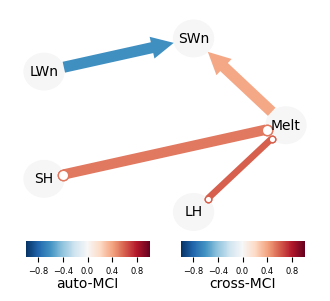

In [89]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/2051_2100/ICE/'
plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2061_2100_conservative_nofdrc_robustparcorr_rmmontrend_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [90]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=link_colors,
    graph=link_types,
    var_names=variables,
    link_width=link_widths,
    save_name=home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2061_2100_conservative_nofdrc_robustparcorr_rmmontrend_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.csv',
    digits=5,
)

In [91]:
save_name = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2061_2100_conservative_nofdrc_robustparcorr_rmmontrend_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.csv'
pd.read_csv(save_name)

,Variable i,Variable j,Time lag of i,Link type i --- j,Link value,Link width
0,Melt,Melt,1,-->,0.00000,0.0
1,Melt,SWn,0,-->,0.39037,44.0
2,Melt,SH,0,o-o,0.52587,41.0
3,Melt,LH,0,o-o,0.59973,26.0
4,SWn,SWn,1,-->,0.00000,0.0
5,SWn,LWn,0,<--,-0.61091,44.0
6,LWn,LWn,1,-->,0.00000,0.0
7,SH,SH,1,-->,0.00000,0.0
8,LH,LH,1,-->,0.00000,0.0


In [92]:
# Save for plotting (since the format saved by tp.write_csv is hard to use)
save_name = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2061_2100_conservative_nofdrc_robustparcorr_rmmontrend_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig_forplot.npz'

np.savez(save_name,
         val_matrix=link_colors,
         graph=link_types,
         link_width=link_widths,
         var_names=np.array(variables))

### Aggregated graph, not divided by std (corrected for significance of self-MCI)

##### without seasonal cycle, max_lag=12, pc_alpha=0.025

In [13]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 12
pc_alpha = 0.025
remove_seasonal_cycle = True
detrend_by_month = True
divide_by_std = False
smooth_width_years = 15

# Initialize storage
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}

# For auto-MCI: store max self-MCI value and significance across ensemble members
node_self_mci_values = defaultdict(list)       # Max auto-MCI values
node_self_mci_significance = defaultdict(list) # Whether max auto-MCI is significant

for n in range(1, 51):  # Loop over 50 ensemble members
    # Load and prepare data
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('2061-01-01','2100-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=remove_seasonal_cycle, add_mask=True, mask_period=[5, 6, 7], detrend_by_month=detrend_by_month, divide_by_std=divide_by_std, smooth_width_years=smooth_width_years)
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    graph = results['graph']
    val_matrix = results['val_matrix']

    # Collect cross-links
    for lag in range(0, max_lag + 1):
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Compute max auto-MCI (across all lags ≥1) and check significance
    for i, var in enumerate(variables):
        # Extract all self-lag values
        self_vals = val_matrix[i, i, 1:]
        max_val = np.max(np.abs(self_vals))   # Max magnitude auto-MCI
        max_lag_idx = np.argmax(np.abs(self_vals)) + 1  # Which lag

        # Check significance: is there a self-link at that lag in the graph?
        is_significant = graph[i, i, max_lag_idx] != '' and graph[i, i, max_lag_idx] != 'o-o'

        node_self_mci_values[var].append(max_val)
        node_self_mci_significance[var].append(is_significant)

In [14]:
# Summarize cross-links as before
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,
                'frequency': freq_count
            }
        else:
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Compute node colors: average max auto-MCI, but set to 0 if not significant in majority of members
summary_nodes = {}
for var in variables:
    # Fraction of members where max auto-MCI is significant
    sig_fraction = np.mean(node_self_mci_significance[var])

    if sig_fraction > 0.5:  # majority significant
        summary_nodes[var] = np.mean(node_self_mci_values[var])
    else:
        summary_nodes[var] = 0.0

In [15]:
# Prepare matrices for cross-links
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

for lag in range(0, max_lag + 1):
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:
            link_types[i, j, lag] = link_type
            link_colors[i, j, lag] = avg_strength
            link_widths[i, j, lag] = frequency

# Node colors: summary_nodes already considers significance
node_colors = [summary_nodes[var] for var in variables]

# Assign node colors to self-link at lag 1 (for plotting)
for i in range(num_vars):
    link_colors[i, i, 1] = node_colors[i]
    link_types[i, i, 1] = '-->'

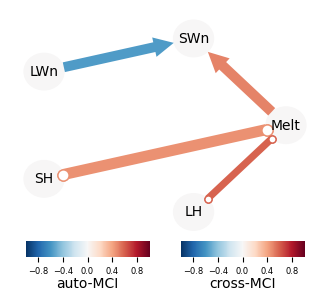

In [16]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/2061_2100/ICE/'
plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2061_2100_conservative_nofdrc_robustparcorr_rmmontrend_nostd_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [17]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=link_colors,
    graph=link_types,
    var_names=variables,
    link_width=link_widths,
    save_name=home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2061_2100_conservative_nofdrc_robustparcorr_rmmontrend_nostd_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.csv',
    digits=5,
)

In [18]:
save_name = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2061_2100_conservative_nofdrc_robustparcorr_rmmontrend_nostd_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.csv'
pd.read_csv(save_name)

,Variable i,Variable j,Time lag of i,Link type i --- j,Link value,Link width
0,Melt,Melt,1,-->,0.00000,0.0
1,Melt,SWn,0,-->,0.49934,43.0
2,Melt,SH,0,o-o,0.45580,47.0
3,Melt,LH,0,o-o,0.59297,30.0
4,SWn,SWn,1,-->,0.00000,0.0
5,SWn,LWn,0,<--,-0.56337,42.0
6,LWn,LWn,1,-->,0.00000,0.0
7,SH,SH,1,-->,0.00000,0.0
8,LH,LH,1,-->,0.00000,0.0


In [19]:
# Save for plotting (since the format saved by tp.write_csv is hard to use)
save_name = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2061_2100_conservative_nofdrc_robustparcorr_rmmontrend_nostd_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig_forplot.npz'

np.savez(save_name,
         val_matrix=link_colors,
         graph=link_types,
         link_width=link_widths,
         var_names=np.array(variables))

##### without seasonal cycle, max_lag=12, pc_alpha=0.05

In [20]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 12
pc_alpha = 0.05
remove_seasonal_cycle = True
detrend_by_month = True
divide_by_std = False
smooth_width_years = 15

# Initialize storage
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}

# For auto-MCI: store max self-MCI value and significance across ensemble members
node_self_mci_values = defaultdict(list)       # Max auto-MCI values
node_self_mci_significance = defaultdict(list) # Whether max auto-MCI is significant

for n in range(1, 51):  # Loop over 50 ensemble members
    # Load and prepare data
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('2061-01-01','2100-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=remove_seasonal_cycle, add_mask=True, mask_period=[5, 6, 7], detrend_by_month=detrend_by_month, divide_by_std=divide_by_std, smooth_width_years=smooth_width_years)
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    graph = results['graph']
    val_matrix = results['val_matrix']

    # Collect cross-links
    for lag in range(0, max_lag + 1):
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Compute max auto-MCI (across all lags ≥1) and check significance
    for i, var in enumerate(variables):
        # Extract all self-lag values
        self_vals = val_matrix[i, i, 1:]
        max_val = np.max(np.abs(self_vals))   # Max magnitude auto-MCI
        max_lag_idx = np.argmax(np.abs(self_vals)) + 1  # Which lag

        # Check significance: is there a self-link at that lag in the graph?
        is_significant = graph[i, i, max_lag_idx] != '' and graph[i, i, max_lag_idx] != 'o-o'

        node_self_mci_values[var].append(max_val)
        node_self_mci_significance[var].append(is_significant)

In [21]:
# Summarize cross-links as before
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,
                'frequency': freq_count
            }
        else:
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Compute node colors: average max auto-MCI, but set to 0 if not significant in majority of members
summary_nodes = {}
for var in variables:
    # Fraction of members where max auto-MCI is significant
    sig_fraction = np.mean(node_self_mci_significance[var])

    if sig_fraction > 0.5:  # majority significant
        summary_nodes[var] = np.mean(node_self_mci_values[var])
    else:
        summary_nodes[var] = 0.0

In [22]:
# Prepare matrices for cross-links
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

for lag in range(0, max_lag + 1):
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:
            link_types[i, j, lag] = link_type
            link_colors[i, j, lag] = avg_strength
            link_widths[i, j, lag] = frequency

# Node colors: summary_nodes already considers significance
node_colors = [summary_nodes[var] for var in variables]

# Assign node colors to self-link at lag 1 (for plotting)
for i in range(num_vars):
    link_colors[i, i, 1] = node_colors[i]
    link_types[i, i, 1] = '-->'

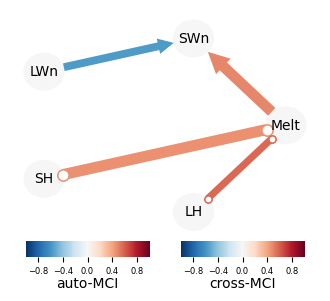

In [23]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/2061_2100/ICE/'
plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2061_2100_conservative_nofdrc_robustparcorr_rmmontrend_nostd_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [24]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=link_colors,
    graph=link_types,
    var_names=variables,
    link_width=link_widths,
    save_name=home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2061_2100_conservative_nofdrc_robustparcorr_rmmontrend_nostd_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.csv',
    digits=5,
)

In [25]:
save_name = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2061_2100_conservative_nofdrc_robustparcorr_rmmontrend_nostd_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.csv'
pd.read_csv(save_name)

,Variable i,Variable j,Time lag of i,Link type i --- j,Link value,Link width
0,Melt,Melt,1,-->,0.00000,0.0
1,Melt,SWn,0,-->,0.48937,42.0
2,Melt,SH,0,o-o,0.45828,44.0
3,Melt,LH,0,o-o,0.57452,28.0
4,SWn,SWn,1,-->,0.00000,0.0
5,SWn,LWn,0,<--,-0.56685,31.0
6,LWn,LWn,1,-->,0.00000,0.0
7,SH,SH,1,-->,0.00000,0.0
8,LH,LH,1,-->,0.00000,0.0


In [26]:
# Save for plotting (since the format saved by tp.write_csv is hard to use)
save_name = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2061_2100_conservative_nofdrc_robustparcorr_rmmontrend_nostd_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig_forplot.npz'

np.savez(save_name,
         val_matrix=link_colors,
         graph=link_types,
         link_width=link_widths,
         var_names=np.array(variables))

##### without seasonal cycle, max_lag=12, pc_alpha=0.1

In [27]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 12
pc_alpha = 0.1
remove_seasonal_cycle = True
detrend_by_month = True
divide_by_std = False
smooth_width_years = 15

# Initialize storage
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}

# For auto-MCI: store max self-MCI value and significance across ensemble members
node_self_mci_values = defaultdict(list)       # Max auto-MCI values
node_self_mci_significance = defaultdict(list) # Whether max auto-MCI is significant

for n in range(1, 51):  # Loop over 50 ensemble members
    # Load and prepare data
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('2061-01-01','2100-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=remove_seasonal_cycle, add_mask=True, mask_period=[5, 6, 7], detrend_by_month=detrend_by_month, divide_by_std=divide_by_std, smooth_width_years=smooth_width_years)
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    graph = results['graph']
    val_matrix = results['val_matrix']

    # Collect cross-links
    for lag in range(0, max_lag + 1):
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Compute max auto-MCI (across all lags ≥1) and check significance
    for i, var in enumerate(variables):
        # Extract all self-lag values
        self_vals = val_matrix[i, i, 1:]
        max_val = np.max(np.abs(self_vals))   # Max magnitude auto-MCI
        max_lag_idx = np.argmax(np.abs(self_vals)) + 1  # Which lag

        # Check significance: is there a self-link at that lag in the graph?
        is_significant = graph[i, i, max_lag_idx] != '' and graph[i, i, max_lag_idx] != 'o-o'

        node_self_mci_values[var].append(max_val)
        node_self_mci_significance[var].append(is_significant)

In [28]:
# Summarize cross-links as before
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,
                'frequency': freq_count
            }
        else:
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Compute node colors: average max auto-MCI, but set to 0 if not significant in majority of members
summary_nodes = {}
for var in variables:
    # Fraction of members where max auto-MCI is significant
    sig_fraction = np.mean(node_self_mci_significance[var])

    if sig_fraction > 0.5:  # majority significant
        summary_nodes[var] = np.mean(node_self_mci_values[var])
    else:
        summary_nodes[var] = 0.0

In [29]:
# Prepare matrices for cross-links
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

for lag in range(0, max_lag + 1):
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:
            link_types[i, j, lag] = link_type
            link_colors[i, j, lag] = avg_strength
            link_widths[i, j, lag] = frequency

# Node colors: summary_nodes already considers significance
node_colors = [summary_nodes[var] for var in variables]

# Assign node colors to self-link at lag 1 (for plotting)
for i in range(num_vars):
    link_colors[i, i, 1] = node_colors[i]
    link_types[i, i, 1] = '-->'

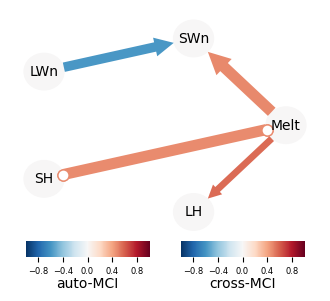

In [30]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/2061_2100/ICE/'
plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2061_2100_conservative_nofdrc_robustparcorr_rmmontrend_nostd_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [31]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=link_colors,
    graph=link_types,
    var_names=variables,
    link_width=link_widths,
    save_name=home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2061_2100_conservative_nofdrc_robustparcorr_rmmontrend_nostd_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.csv',
    digits=5,
)

In [32]:
save_name = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2061_2100_conservative_nofdrc_robustparcorr_rmmontrend_nostd_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.csv'
pd.read_csv(save_name)

,Variable i,Variable j,Time lag of i,Link type i --- j,Link value,Link width
0,Melt,Melt,1,-->,0.00000,0.0
1,Melt,SWn,0,-->,0.48133,35.0
2,Melt,SH,0,o-o,0.46921,35.0
3,Melt,LH,0,-->,0.56586,21.0
4,SWn,SWn,1,-->,0.00000,0.0
5,SWn,LWn,0,<--,-0.58139,30.0
6,LWn,LWn,1,-->,0.00000,0.0
7,SH,SH,1,-->,0.00000,0.0
8,LH,LH,1,-->,0.00000,0.0


In [33]:
# Save for plotting (since the format saved by tp.write_csv is hard to use)
save_name = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2061_2100_conservative_nofdrc_robustparcorr_rmmontrend_nostd_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig_forplot.npz'

np.savez(save_name,
         val_matrix=link_colors,
         graph=link_types,
         link_width=link_widths,
         var_names=np.array(variables))

In [13]:
# ===== Save contemporaneous strengths (lag=0) regardless of direction =====
pairs = [('SWn', 'Melt'), ('SH', 'Melt'), ('LH', 'Melt')]
var_to_idx = {v: i for i, v in enumerate(variables)}

lag0 = 0
valid_types = {'-->', '<--', 'o-o', 'x-x'}   # anything not '' counts as a detected contemporaneous link

# Infer number of members from any stored list at lag 0
# (fall back to 50 if unavailable, but your lists should have length 50)
_sample_key = next(iter(link_types_by_lag[lag0]))
n_members = len(link_types_by_lag[lag0][_sample_key]) if link_types_by_lag[lag0] else 50

out = {}

for a, b in pairs:
    i, j = var_to_idx[a], var_to_idx[b]

    # Get lists across members; guard if a key is missing
    types_ij   = link_types_by_lag[lag0].get((i, j),   [''] * n_members)
    types_ji   = link_types_by_lag[lag0].get((j, i),   [''] * n_members)
    streng_ij  = link_strengths_by_lag[lag0].get((i, j), [np.nan] * n_members)
    streng_ji  = link_strengths_by_lag[lag0].get((j, i), [np.nan] * n_members)

    sym_strength = np.full(n_members, np.nan, dtype=float)

    for k in range(n_members):
        s_list = []
        if types_ij[k] in valid_types and np.isfinite(streng_ij[k]):
            s_list.append(streng_ij[k])
        if types_ji[k] in valid_types and np.isfinite(streng_ji[k]):
            s_list.append(streng_ji[k])

        # mean absolute strength across whatever directions were detected this member
        if s_list:
            sym_strength[k] = float(np.mean(s_list))  # could use max(s_list) if you prefer

    out[f'{a}_to_{b}_lag0_anydir'] = sym_strength

# (Optional) also save direction tallies per member for auditing
dir_counts = {}
for a, b in pairs:
    i, j = var_to_idx[a], var_to_idx[b]
    types_ij = link_types_by_lag[lag0].get((i, j), [''] * n_members)
    types_ji = link_types_by_lag[lag0].get((j, i), [''] * n_members)
    dir_counts[f'{a}_{b}_dir_ij'] = np.array(types_ij, dtype='U3')
    dir_counts[f'{a}_{b}_dir_ji'] = np.array(types_ji, dtype='U3')

save_path = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/lens2_2071_2100_contemp_strengths_anydir_SWn_SH_LH_Melt_lag0.npz'
np.savez(
    save_path,
    **out,
    **dir_counts,
    meta=np.array([
        "Definition: per-member mean |cross-MCI| at lag=0 across any detected direction "
        "(i→j and/or j→i); NaN = no contemporaneous link detected in either direction.",
        f"variables: {variables}",
        f"pc_alpha={pc_alpha}, remove_seasonal_cycle={remove_seasonal_cycle}, mask=JJA"
    ], dtype=object),
)
print(f"Saved contemporaneous strengths (any direction) to: {save_path}")

Saved contemporaneous strengths (any direction) to: /glade/work/ziqiyin/2023-GrIS-melt-causality/data/LENS2/ICE/lens2_2071_2100_contemp_strengths_anydir_SWn_SH_LH_Melt_lag0.npz


In [14]:
# Read in and plot
data = np.load(save_path, allow_pickle=True)

SWn_strength = data['SWn_to_Melt_lag0_anydir']
SH_strength  = data['SH_to_Melt_lag0_anydir']
LH_strength  = data['LH_to_Melt_lag0_anydir']

print("SWn-Melt strengths:", SWn_strength)
print("Mean:", np.nanmean(SWn_strength))
print("Number of valid detections:", np.sum(~np.isnan(SWn_strength)))
print("")
print("SH-Melt strengths:", SH_strength)
print("Mean:", np.nanmean(SH_strength))
print("Number of valid detections:", np.sum(~np.isnan(SH_strength)))
print("")
print("LH-Melt strengths:", LH_strength)
print("Mean:", np.nanmean(LH_strength))
print("Number of valid detections:", np.sum(~np.isnan(LH_strength)))

SWn-Melt strengths: [0.32155197 0.28265793 0.37032562 0.38247561 0.31375141 0.42958276
 0.39272342 0.35028681 0.25531738 0.25821962 0.46347625 0.70807606
 0.30629568 0.36522548 0.39807807 0.37275485 0.24453214 0.29481426
 0.56177981 0.26294576 0.24124434 0.61158352 0.24046752        nan
 0.40914725 0.31050179 0.57783031 0.38546354 0.23493858 0.26960991
 0.51692114 0.37196645 0.47498946 0.32169499 0.58889377 0.58393331
 0.32997144 0.45844703 0.19636831 0.2911998  0.38642637 0.31973802
 0.33043141 0.2043404  0.41566398 0.24162738 0.28506919 0.33213835
        nan 0.63297566]
Mean: 0.37288446032093553
Number of valid detections: 48

SH-Melt strengths: [0.40931357 0.26087719 0.56893933 0.50412911 0.39299719 0.59309236
 0.64385174 0.43894142 0.59637804 0.75371393 0.52722039 0.58329578
 0.46035301 0.49657046 0.46668939 0.4842625  0.44576009 0.53160194
 0.3558332  0.45540256 0.70700851 0.53044989 0.46559295 0.74003116
 0.55081637 0.29529321 0.57352268 0.37369498 0.39697034 0.68211375
 0.25092

In [35]:
# ===== Save contemporaneous strengths (lag=0) for the most-frequent link type =====
pairs = [('SWn', 'Melt'), ('SH', 'Melt'), ('LH', 'Melt')]
var_to_idx = {v: i for i, v in enumerate(variables)}

lag0 = 0
valid_types = {'-->', '<--', 'o-o', 'x-x'}  # contemporaneous link encodings

# Infer number of members
_sample_key = next(iter(link_types_by_lag[lag0]))
n_members = len(link_types_by_lag[lag0][_sample_key]) if link_types_by_lag[lag0] else 50

def consolidate_type(t_ij, t_ji):
    """Pick a single contemporaneous type for this member between vars i and j."""
    # Prefer explicit types; if both present but mismatch, pick a stable rule:
    # If either is undirected, treat as undirected; else prefer '-->' or '<--' if present.
    if t_ij in valid_types and t_ji in valid_types:
        if ('o-o' in (t_ij, t_ji)) or ('x-x' in (t_ij, t_ji)):
            return 'o-o' if 'o-o' in (t_ij, t_ji) else 'x-x'
        # If both are directed but inconsistent, prefer t_ij (stable, deterministic)
        return t_ij
    if t_ij in valid_types:
        return t_ij
    if t_ji in valid_types:
        # Map the (j,i) direction into the canonical i–j viewpoint:
        # If (j,i) shows '-->' that means j→i, i.e., '<--' for (i,j)
        if t_ji == '-->':
            return '<--'
        if t_ji == '<--':
            return '-->'
        return t_ji  # 'o-o' or 'x-x'
    return ''  # no contemporaneous link detected

# Priority for final tie-break if needed
type_priority = ['-->', '<--', 'o-o', 'x-x']

out = {}
dir_counts = {}
mf_type_meta = {}
mf_type_counts = {}
mf_type_mean_strength = {}

for a, b in pairs:
    i, j = var_to_idx[a], var_to_idx[b]

    types_ij  = link_types_by_lag[lag0].get((i, j),   [''] * n_members)
    types_ji  = link_types_by_lag[lag0].get((j, i),   [''] * n_members)
    streng_ij = link_strengths_by_lag[lag0].get((i, j), [np.nan] * n_members)
    streng_ji = link_strengths_by_lag[lag0].get((j, i), [np.nan] * n_members)

    # Per-member consolidated type (one of '-->','<--','o-o','x-x','')
    cons_types = np.array(
        [consolidate_type(types_ij[k], types_ji[k]) for k in range(n_members)],
        dtype='U3'
    )

    # Count frequencies among *detected* types (exclude '')
    counts = {t: int(np.sum(cons_types == t)) for t in valid_types}

    # If no detections at all, keep all-NaN and record 'none'
    if sum(counts.values()) == 0:
        out[f'{a}_to_{b}_lag0_mostfreq'] = np.full(n_members, np.nan, dtype=float)
        mf_type_meta[f'{a}_{b}_mostfreq_type'] = 'none'
        mf_type_counts[f'{a}_{b}_counts'] = counts
        mf_type_mean_strength[f'{a}_{b}_type_means'] = {t: np.nan for t in valid_types}
        # Keep auditing arrays
        dir_counts[f'{a}_{b}_dir_ij'] = np.array(types_ij, dtype='U3')
        dir_counts[f'{a}_{b}_dir_ji'] = np.array(types_ji, dtype='U3')
        continue

    # Candidate types with max count
    max_count = max(counts.values())
    tied = [t for t, c in counts.items() if c == max_count and c > 0]

    # For tie-break: compute mean |strength| across members that *have that type*
    def member_strength_for_type(k, t):
        if t == '-->':  # i -> j
            return streng_ij[k] if np.isfinite(streng_ij[k]) else np.nan
        if t == '<--':  # j -> i
            return streng_ji[k] if np.isfinite(streng_ji[k]) else np.nan
        if t in ('o-o', 'x-x'):
            # mean of available directions (your prior choice)
            vals = []
            if np.isfinite(streng_ij[k]): vals.append(streng_ij[k])
            if np.isfinite(streng_ji[k]): vals.append(streng_ji[k])
            return np.mean(vals) if len(vals) else np.nan
        return np.nan

    type_means = {}
    for t in valid_types:
        idx = np.where(cons_types == t)[0]
        if idx.size == 0:
            type_means[t] = np.nan
        else:
            vals = [member_strength_for_type(k, t) for k in idx]
            vals = np.array(vals, dtype=float)
            type_means[t] = float(np.nanmean(np.abs(vals))) if np.isfinite(vals).any() else np.nan

    if len(tied) > 1:
        # Prefer the one with larger mean |strength|
        means_tied = {t: (type_means[t] if np.isfinite(type_means[t]) else -np.inf) for t in tied}
        best_mean = max(means_tied.values())
        tied_best = [t for t, m in means_tied.items() if m == best_mean]
        if len(tied_best) == 1:
            chosen = tied_best[0]
        else:
            # Final deterministic priority
            for t in type_priority:
                if t in tied_best:
                    chosen = t
                    break
    else:
        chosen = tied[0]

    # Build the per-member strength vector ONLY for the chosen type
    strengths_mf = np.full(n_members, np.nan, dtype=float)
    for k in range(n_members):
        if cons_types[k] == chosen:
            strengths_mf[k] = member_strength_for_type(k, chosen)

    out[f'{a}_to_{b}_lag0_mostfreq'] = strengths_mf
    mf_type_meta[f'{a}_{b}_mostfreq_type'] = chosen
    mf_type_counts[f'{a}_{b}_counts'] = counts
    mf_type_mean_strength[f'{a}_{b}_type_means'] = type_means

    # (Optional) keep raw type audits like before
    dir_counts[f'{a}_{b}_dir_ij'] = np.array(types_ij, dtype='U3')
    dir_counts[f'{a}_{b}_dir_ji'] = np.array(types_ji, dtype='U3')

# ==== Save ====
save_path = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/lens2_2061_2100_contemp_strengths_mostfreq_SWn_SH_LH_Melt_lag0_rmmontrend_nostd.npz'
np.savez(
    save_path,
    **out,
    **dir_counts,
    mf_type=np.array(mf_type_meta, dtype=object),
    mf_counts=np.array(mf_type_counts, dtype=object),
    mf_type_means=np.array(mf_type_mean_strength, dtype=object),
    meta=np.array([
        "Definition: per-member |cross-MCI| at lag=0 ONLY for the ensemble's most-frequent"
        " contemporaneous link type (among '-->','<--','o-o','x-x') per pair;"
        " members not matching that type are NaN.",
        "Tie-breaks: higher mean |strength| across tied types, then priority ['-->','<--','o-o','x-x'].",
        f"variables: {variables}",
        f"pc_alpha={pc_alpha}, remove_seasonal_cycle={remove_seasonal_cycle}, mask=JJA"
    ], dtype=object),
)
print(f"Saved contemporaneous strengths (most frequent type) to: {save_path}")

Saved contemporaneous strengths (most frequent type) to: /glade/work/ziqiyin/2023-GrIS-melt-causality/data/LENS2/ICE/lens2_2061_2100_contemp_strengths_mostfreq_SWn_SH_LH_Melt_lag0_rmmontrend_nostd.npz


In [36]:
# Read in and plot
data = np.load(save_path, allow_pickle=True)

SWn_strength = data['SWn_to_Melt_lag0_mostfreq']
SH_strength  = data['SH_to_Melt_lag0_mostfreq']
LH_strength  = data['LH_to_Melt_lag0_mostfreq']

print("SWn-Melt strengths:", SWn_strength)
print("Mean:", np.nanmean(SWn_strength))
print("Min:", np.nanmin(SWn_strength))
print("Max:", np.nanmax(SWn_strength))
print("Number of valid detections:", np.sum(~np.isnan(SWn_strength)))
print("")
print("SH-Melt strengths:", SH_strength)
print("Mean:", np.nanmean(SH_strength))
print("Min:", np.nanmin(SH_strength))
print("Max:", np.nanmax(SH_strength))
print("Number of valid detections:", np.sum(~np.isnan(SH_strength)))
print("")
print("LH-Melt strengths:", LH_strength)
print("Mean:", np.nanmean(LH_strength))
print("Min:", np.nanmin(LH_strength))
print("Max:", np.nanmax(LH_strength))
print("Number of valid detections:", np.sum(~np.isnan(LH_strength)))

SWn-Melt strengths: [0.55777319 0.41110091 0.54708166 0.36127863 0.50761769 0.40032429
 0.54154967 0.39236703 0.49246462 0.50669155 0.51902884        nan
 0.46518412        nan 0.48871248        nan 0.45691333        nan
 0.59528321 0.35116902        nan        nan 0.42084368 0.4494459
        nan 0.41125282 0.51358354        nan        nan 0.44747213
 0.553973   0.61110109        nan 0.50430634 0.57735822        nan
 0.48785854        nan 0.43804736 0.49426528        nan 0.50665243
        nan 0.35065811 0.46152761 0.49806268        nan 0.50238505
 0.39104016 0.63232299]
Mean: 0.48133420428247076
Min: 0.3506581124891136
Max: 0.6323229870080435
Number of valid detections: 35

SH-Melt strengths: [0.38891439        nan 0.51071724 0.6838997  0.41543913 0.31666234
 0.48267153 0.52919947 0.58257329 0.60080771 0.43218266        nan
        nan 0.42723869        nan 0.52771393 0.55944694        nan
 0.43834551 0.71609488 0.30297691        nan 0.58545948        nan
 0.33534949 0.30948696 0.627

##### without seasonal cycle, max_lag=12, pc_alpha=None

In [37]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 12
pc_alpha = None
remove_seasonal_cycle = True
detrend_by_month = True
divide_by_std = False
smooth_width_years = 15

# Initialize storage
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}

# For auto-MCI: store max self-MCI value and significance across ensemble members
node_self_mci_values = defaultdict(list)       # Max auto-MCI values
node_self_mci_significance = defaultdict(list) # Whether max auto-MCI is significant

for n in range(1, 51):  # Loop over 50 ensemble members
    # Load and prepare data
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('2061-01-01','2100-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=remove_seasonal_cycle, add_mask=True, mask_period=[5, 6, 7], detrend_by_month=detrend_by_month, divide_by_std=divide_by_std, smooth_width_years=smooth_width_years)
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    graph = results['graph']
    val_matrix = results['val_matrix']

    # Collect cross-links
    for lag in range(0, max_lag + 1):
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Compute max auto-MCI (across all lags ≥1) and check significance
    for i, var in enumerate(variables):
        # Extract all self-lag values
        self_vals = val_matrix[i, i, 1:]
        max_val = np.max(np.abs(self_vals))   # Max magnitude auto-MCI
        max_lag_idx = np.argmax(np.abs(self_vals)) + 1  # Which lag

        # Check significance: is there a self-link at that lag in the graph?
        is_significant = graph[i, i, max_lag_idx] != '' and graph[i, i, max_lag_idx] != 'o-o'

        node_self_mci_values[var].append(max_val)
        node_self_mci_significance[var].append(is_significant)

In [38]:
# Summarize cross-links as before
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,
                'frequency': freq_count
            }
        else:
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Compute node colors: average max auto-MCI, but set to 0 if not significant in majority of members
summary_nodes = {}
for var in variables:
    # Fraction of members where max auto-MCI is significant
    sig_fraction = np.mean(node_self_mci_significance[var])

    if sig_fraction > 0.5:  # majority significant
        summary_nodes[var] = np.mean(node_self_mci_values[var])
    else:
        summary_nodes[var] = 0.0

In [39]:
# Prepare matrices for cross-links
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

for lag in range(0, max_lag + 1):
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:
            link_types[i, j, lag] = link_type
            link_colors[i, j, lag] = avg_strength
            link_widths[i, j, lag] = frequency

# Node colors: summary_nodes already considers significance
node_colors = [summary_nodes[var] for var in variables]

# Assign node colors to self-link at lag 1 (for plotting)
for i in range(num_vars):
    link_colors[i, i, 1] = node_colors[i]
    link_types[i, i, 1] = '-->'

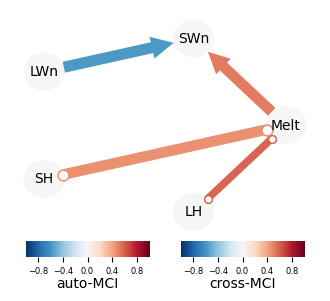

In [40]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/2051_2100/ICE/'
plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2061_2100_conservative_nofdrc_robustparcorr_rmmontrend_nostd_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [41]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=link_colors,
    graph=link_types,
    var_names=variables,
    link_width=link_widths,
    save_name=home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2061_2100_conservative_nofdrc_robustparcorr_rmmontrend_nostd_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.csv',
    digits=5,
)

In [42]:
save_name = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2061_2100_conservative_nofdrc_robustparcorr_rmmontrend_nostd_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.csv'
pd.read_csv(save_name)

,Variable i,Variable j,Time lag of i,Link type i --- j,Link value,Link width
0,Melt,Melt,1,-->,0.00000,0.0
1,Melt,SWn,0,-->,0.51666,48.0
2,Melt,SH,0,o-o,0.45349,48.0
3,Melt,LH,0,o-o,0.58553,34.0
4,SWn,SWn,1,-->,0.00000,0.0
5,SWn,LWn,0,<--,-0.57534,50.0
6,LWn,LWn,1,-->,0.00000,0.0
7,SH,SH,1,-->,0.00000,0.0
8,LH,LH,1,-->,0.00000,0.0


In [43]:
# Save for plotting (since the format saved by tp.write_csv is hard to use)
save_name = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2061_2100_conservative_nofdrc_robustparcorr_rmmontrend_nostd_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig_forplot.npz'

np.savez(save_name,
         val_matrix=link_colors,
         graph=link_types,
         link_width=link_widths,
         var_names=np.array(variables))

##### without seasonal cycle, max_lag=6, pc_alpha=0.1

In [48]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 6
pc_alpha = 0.1
remove_seasonal_cycle = True

# Initialize storage
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}

# For auto-MCI: store max self-MCI value and significance across ensemble members
node_self_mci_values = defaultdict(list)       # Max auto-MCI values
node_self_mci_significance = defaultdict(list) # Whether max auto-MCI is significant

for n in range(1, 51):  # Loop over 50 ensemble members
    # Load and prepare data
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('2071-01-01','2100-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=remove_seasonal_cycle, add_mask=True, mask_period=[5, 6, 7])
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    graph = results['graph']
    val_matrix = results['val_matrix']

    # Collect cross-links
    for lag in range(0, max_lag + 1):
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Compute max auto-MCI (across all lags ≥1) and check significance
    for i, var in enumerate(variables):
        # Extract all self-lag values
        self_vals = val_matrix[i, i, 1:]
        max_val = np.max(np.abs(self_vals))   # Max magnitude auto-MCI
        max_lag_idx = np.argmax(np.abs(self_vals)) + 1  # Which lag

        # Check significance: is there a self-link at that lag in the graph?
        is_significant = graph[i, i, max_lag_idx] != '' and graph[i, i, max_lag_idx] != 'o-o'

        node_self_mci_values[var].append(max_val)
        node_self_mci_significance[var].append(is_significant)

In [49]:
# Summarize cross-links as before
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,
                'frequency': freq_count
            }
        else:
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Compute node colors: average max auto-MCI, but set to 0 if not significant in majority of members
summary_nodes = {}
for var in variables:
    # Fraction of members where max auto-MCI is significant
    sig_fraction = np.mean(node_self_mci_significance[var])

    if sig_fraction > 0.5:  # majority significant
        summary_nodes[var] = np.mean(node_self_mci_values[var])
    else:
        summary_nodes[var] = 0.0

In [50]:
# Prepare matrices for cross-links
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

for lag in range(0, max_lag + 1):
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:
            link_types[i, j, lag] = link_type
            link_colors[i, j, lag] = avg_strength
            link_widths[i, j, lag] = frequency

# Node colors: summary_nodes already considers significance
node_colors = [summary_nodes[var] for var in variables]

# Assign node colors to self-link at lag 1 (for plotting)
for i in range(num_vars):
    link_colors[i, i, 1] = node_colors[i]
    link_types[i, i, 1] = '-->'

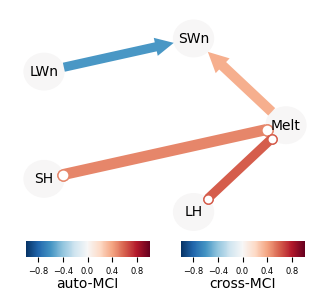

In [51]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/2071_2100/ICE/'
plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2071_2100_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [52]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=link_colors,
    graph=link_types,
    var_names=variables,
    link_width=link_widths,
    save_name=home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2071_2100_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.csv',
    digits=5,
)

In [53]:
save_name = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2071_2100_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.csv'
pd.read_csv(save_name)

,Variable i,Variable j,Time lag of i,Link type i --- j,Link value,Link width
0,Melt,Melt,1,-->,0.00000,0.0
1,Melt,SWn,0,-->,0.36189,32.0
2,Melt,SH,0,o-o,0.49144,35.0
3,Melt,LH,0,o-o,0.60834,29.0
4,SWn,SWn,1,-->,0.00000,0.0
5,SWn,LWn,0,<--,-0.58041,29.0
6,LWn,LWn,1,-->,0.00000,0.0
7,SH,SH,1,-->,0.00000,0.0
8,LH,LH,1,-->,0.00000,0.0


In [54]:
# Save for plotting (since the format saved by tp.write_csv is hard to use)
save_name = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2071_2100_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig_forplot.npz'

np.savez(save_name,
         val_matrix=link_colors,
         graph=link_types,
         link_width=link_widths,
         var_names=np.array(variables))

##### without seasonal cycle, max_lag=18, pc_alpha=0.1

In [55]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 18
pc_alpha = 0.1
remove_seasonal_cycle = True

# Initialize storage
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}

# For auto-MCI: store max self-MCI value and significance across ensemble members
node_self_mci_values = defaultdict(list)       # Max auto-MCI values
node_self_mci_significance = defaultdict(list) # Whether max auto-MCI is significant

for n in range(1, 51):  # Loop over 50 ensemble members
    # Load and prepare data
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('2071-01-01','2100-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=remove_seasonal_cycle, add_mask=True, mask_period=[5, 6, 7])
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    graph = results['graph']
    val_matrix = results['val_matrix']

    # Collect cross-links
    for lag in range(0, max_lag + 1):
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Compute max auto-MCI (across all lags ≥1) and check significance
    for i, var in enumerate(variables):
        # Extract all self-lag values
        self_vals = val_matrix[i, i, 1:]
        max_val = np.max(np.abs(self_vals))   # Max magnitude auto-MCI
        max_lag_idx = np.argmax(np.abs(self_vals)) + 1  # Which lag

        # Check significance: is there a self-link at that lag in the graph?
        is_significant = graph[i, i, max_lag_idx] != '' and graph[i, i, max_lag_idx] != 'o-o'

        node_self_mci_values[var].append(max_val)
        node_self_mci_significance[var].append(is_significant)

In [56]:
# Summarize cross-links as before
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,
                'frequency': freq_count
            }
        else:
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Compute node colors: average max auto-MCI, but set to 0 if not significant in majority of members
summary_nodes = {}
for var in variables:
    # Fraction of members where max auto-MCI is significant
    sig_fraction = np.mean(node_self_mci_significance[var])

    if sig_fraction > 0.5:  # majority significant
        summary_nodes[var] = np.mean(node_self_mci_values[var])
    else:
        summary_nodes[var] = 0.0

In [57]:
# Prepare matrices for cross-links
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

for lag in range(0, max_lag + 1):
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:
            link_types[i, j, lag] = link_type
            link_colors[i, j, lag] = avg_strength
            link_widths[i, j, lag] = frequency

# Node colors: summary_nodes already considers significance
node_colors = [summary_nodes[var] for var in variables]

# Assign node colors to self-link at lag 1 (for plotting)
for i in range(num_vars):
    link_colors[i, i, 1] = node_colors[i]
    link_types[i, i, 1] = '-->'

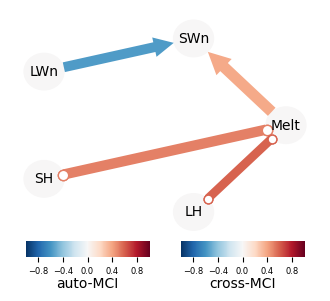

In [58]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/2071_2100/ICE/'
plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2071_2100_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [59]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=link_colors,
    graph=link_types,
    var_names=variables,
    link_width=link_widths,
    save_name=home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2071_2100_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.csv',
    digits=5,
)

In [60]:
save_name = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2071_2100_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.csv'
pd.read_csv(save_name)

,Variable i,Variable j,Time lag of i,Link type i --- j,Link value,Link width
0,Melt,Melt,1,-->,0.00000,0.0
1,Melt,SWn,0,-->,0.37554,28.0
2,Melt,SH,0,o-o,0.50337,26.0
3,Melt,LH,0,o-o,0.58747,22.0
4,SWn,SWn,1,-->,0.00000,0.0
5,SWn,LWn,0,<--,-0.56284,25.0
6,LWn,LWn,1,-->,0.00000,0.0
7,SH,SH,1,-->,0.00000,0.0
8,LH,LH,1,-->,0.00000,0.0


In [61]:
# Save for plotting (since the format saved by tp.write_csv is hard to use)
save_name = home_dir+'2023-GrIS-melt-causality/data/LENS2/ICE/graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2071_2100_conservative_nofdrc_robustparcorr_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig_forplot.npz'

np.savez(save_name,
         val_matrix=link_colors,
         graph=link_types,
         link_width=link_widths,
         var_names=np.array(variables))

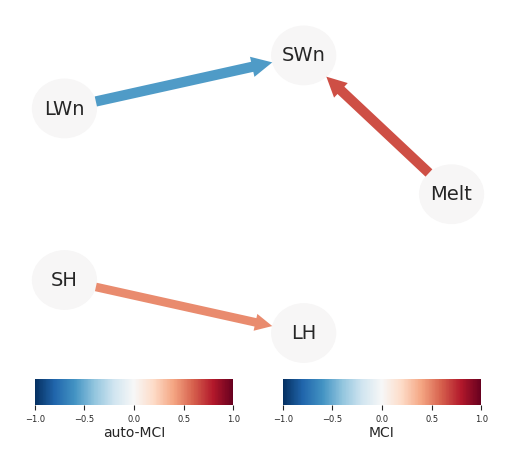

In [40]:
# alpha = 0.01
pc_alpha_bootstrap = 0.01
boot_samples = 100
tau_max = 15

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 1

## Create PCMCI object to call run_bootstrap_of
pcmci = PCMCI(dataframe=dataframe,
        cond_ind_test=robustparcorr,
        verbosity=0,
        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus',
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean']

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=dataframe.var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/clean_seasonality_mask/withoutism/'
plt.savefig(plot_dir+'graph_pcmciplus_bootstrap_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_ablation_seasonality_LENS2'+num+'_conservative_nofdrc_robustparcorr_taumax15_alpha001_clean.png', dpi = 300, bbox_inches = 'tight', facecolor='w', transparent = False)

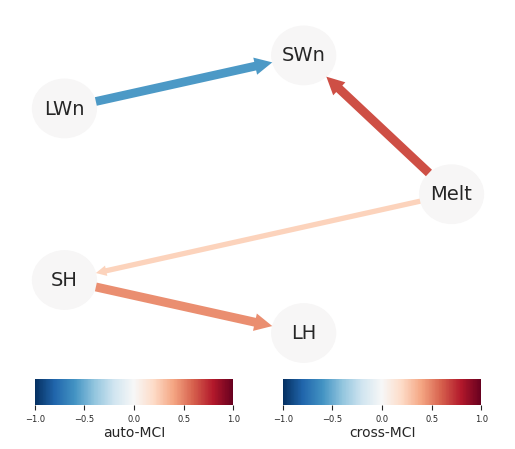

In [41]:
# alpha = 0.025
pc_alpha_bootstrap = 0.025
boot_samples = 100
tau_max = 15

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 1

## Create PCMCI object to call run_bootstrap_of
pcmci = PCMCI(dataframe=dataframe,
        cond_ind_test=robustparcorr,
        verbosity=0,
        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean']

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=dataframe.var_names,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plt.savefig(plot_dir+'graph_pcmciplus_bootstrap_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_ablation_seasonality_LENS2'+num+'_conservative_nofdrc_robustparcorr_taumax15_alpha0025_clean.png', dpi = 300, bbox_inches = 'tight', facecolor='w', transparent = False)

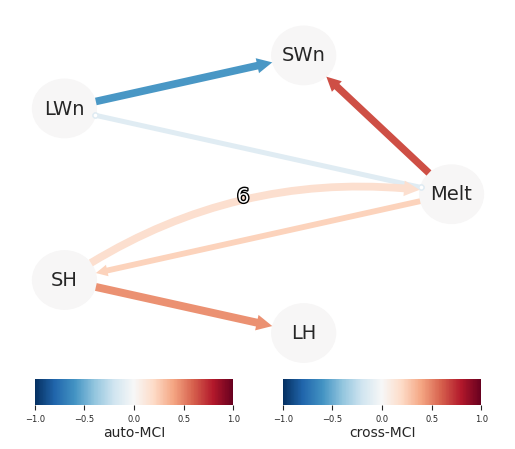

In [42]:
# alpha = 0.05
pc_alpha_bootstrap = 0.05
boot_samples = 100
tau_max = 15

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 1

## Create PCMCI object to call run_bootstrap_of
pcmci = PCMCI(dataframe=dataframe,
        cond_ind_test=robustparcorr,
        verbosity=0,
        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean']

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=dataframe.var_names,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plt.savefig(plot_dir+'graph_pcmciplus_bootstrap_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_ablation_seasonality_LENS2'+num+'_conservative_nofdrc_robustparcorr_taumax15_alpha005_clean.png', dpi = 300, bbox_inches = 'tight', facecolor='w', transparent = False)

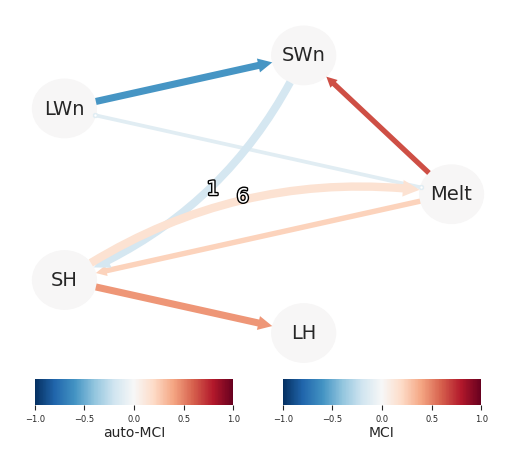

In [43]:
# alpha = 0.1
pc_alpha_bootstrap = 0.1
boot_samples = 100
tau_max = 15

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 1

## Create PCMCI object to call run_bootstrap_of
pcmci = PCMCI(dataframe=dataframe,
        cond_ind_test=robustparcorr,
        verbosity=0,
        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean']

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=dataframe.var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    ); 

plt.savefig(plot_dir+'graph_pcmciplus_bootstrap_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_ablation_seasonality_LENS2'+num+'_conservative_nofdrc_robustparcorr_taumax15_alpha01_clean.png', dpi = 300, bbox_inches = 'tight', facecolor='w', transparent = False)

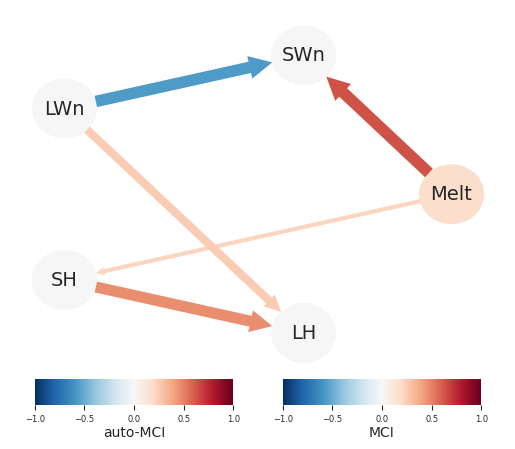

In [44]:
# alpha = None
pc_alpha_bootstrap = None
boot_samples = 100
tau_max = 15

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 1

## Create PCMCI object to call run_bootstrap_of
pcmci = PCMCI(dataframe=dataframe,
        cond_ind_test=robustparcorr,
        verbosity=0,
        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean']

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=dataframe.var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plt.savefig(plot_dir+'graph_pcmciplus_bootstrap_melt_SEB_noGHF_F09BHIST_realJJA_GrIS_ablation_seasonality_LENS2'+num+'_conservative_nofdrc_robustparcorr_taumax15_alphaNone_clean.png', dpi = 300, bbox_inches = 'tight', facecolor='w', transparent = False)

## Test

##### without seasonal cycle, max_lag=12, pc_alpha=0.1

In [10]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 12
pc_alpha = 0.1
remove_seasonal_cycle = True
detrend_by_month = True
divide_by_std = False
smooth_width_years = 15

# Initialize storage
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}

# For auto-MCI: store max self-MCI value and significance across ensemble members
node_self_mci_values = defaultdict(list)       # Max auto-MCI values
node_self_mci_significance = defaultdict(list) # Whether max auto-MCI is significant

for n in range(1, 51):  # Loop over 50 ensemble members
    # Load and prepare data
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('2071-01-01','2100-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=remove_seasonal_cycle, add_mask=True, mask_period=[5, 6, 7], detrend_by_month=detrend_by_month, divide_by_std=divide_by_std, smooth_width_years=smooth_width_years)
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='majority')

    graph = results['graph']
    val_matrix = results['val_matrix']

    # Collect cross-links
    for lag in range(0, max_lag + 1):
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Compute max auto-MCI (across all lags ≥1) and check significance
    for i, var in enumerate(variables):
        # Extract all self-lag values
        self_vals = val_matrix[i, i, 1:]
        max_val = np.max(np.abs(self_vals))   # Max magnitude auto-MCI
        max_lag_idx = np.argmax(np.abs(self_vals)) + 1  # Which lag

        # Check significance: is there a self-link at that lag in the graph?
        is_significant = graph[i, i, max_lag_idx] != '' and graph[i, i, max_lag_idx] != 'o-o'

        node_self_mci_values[var].append(max_val)
        node_self_mci_significance[var].append(is_significant)

In [11]:
# Summarize cross-links as before
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,
                'frequency': freq_count
            }
        else:
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Compute node colors: average max auto-MCI, but set to 0 if not significant in majority of members
summary_nodes = {}
for var in variables:
    # Fraction of members where max auto-MCI is significant
    sig_fraction = np.mean(node_self_mci_significance[var])

    if sig_fraction > 0.5:  # majority significant
        summary_nodes[var] = np.mean(node_self_mci_values[var])
    else:
        summary_nodes[var] = 0.0

In [12]:
# Prepare matrices for cross-links
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

for lag in range(0, max_lag + 1):
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:
            link_types[i, j, lag] = link_type
            link_colors[i, j, lag] = avg_strength
            link_widths[i, j, lag] = frequency

# Node colors: summary_nodes already considers significance
node_colors = [summary_nodes[var] for var in variables]

# Assign node colors to self-link at lag 1 (for plotting)
for i in range(num_vars):
    link_colors[i, i, 1] = node_colors[i]
    link_types[i, i, 1] = '-->'

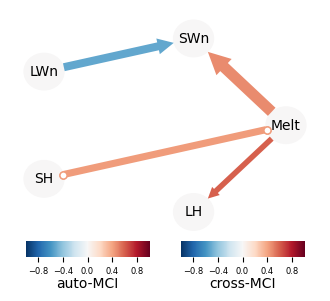

In [13]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/2071_2100/ICE/'
plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2071_2100_majority_nofdrc_robustparcorr_rmmontrend_nostd_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

##### without seasonal cycle, max_lag=12, pc_alpha=0.1, smooth_width_years = 10

In [55]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 12
pc_alpha = 0.1
remove_seasonal_cycle = True
detrend_by_month = True
divide_by_std = False
smooth_width_years = 20

# Initialize storage
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}

# For auto-MCI: store max self-MCI value and significance across ensemble members
node_self_mci_values = defaultdict(list)       # Max auto-MCI values
node_self_mci_significance = defaultdict(list) # Whether max auto-MCI is significant

for n in range(1, 51):  # Loop over 50 ensemble members
    # Load and prepare data
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('2061-01-01','2100-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=remove_seasonal_cycle, add_mask=True, mask_period=[5, 6, 7], detrend_by_month=detrend_by_month, divide_by_std=divide_by_std, smooth_width_years=smooth_width_years)
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    graph = results['graph']
    val_matrix = results['val_matrix']

    # Collect cross-links
    for lag in range(0, max_lag + 1):
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Compute max auto-MCI (across all lags ≥1) and check significance
    for i, var in enumerate(variables):
        # Extract all self-lag values
        self_vals = val_matrix[i, i, 1:]
        max_val = np.max(np.abs(self_vals))   # Max magnitude auto-MCI
        max_lag_idx = np.argmax(np.abs(self_vals)) + 1  # Which lag

        # Check significance: is there a self-link at that lag in the graph?
        is_significant = graph[i, i, max_lag_idx] != '' and graph[i, i, max_lag_idx] != 'o-o'

        node_self_mci_values[var].append(max_val)
        node_self_mci_significance[var].append(is_significant)

In [56]:
# Summarize cross-links as before
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,
                'frequency': freq_count
            }
        else:
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Compute node colors: average max auto-MCI, but set to 0 if not significant in majority of members
summary_nodes = {}
for var in variables:
    # Fraction of members where max auto-MCI is significant
    sig_fraction = np.mean(node_self_mci_significance[var])

    if sig_fraction > 0.5:  # majority significant
        summary_nodes[var] = np.mean(node_self_mci_values[var])
    else:
        summary_nodes[var] = 0.0

In [57]:
# Prepare matrices for cross-links
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

for lag in range(0, max_lag + 1):
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:
            link_types[i, j, lag] = link_type
            link_colors[i, j, lag] = avg_strength
            link_widths[i, j, lag] = frequency

# Node colors: summary_nodes already considers significance
node_colors = [summary_nodes[var] for var in variables]

# Assign node colors to self-link at lag 1 (for plotting)
for i in range(num_vars):
    link_colors[i, i, 1] = node_colors[i]
    link_types[i, i, 1] = '-->'

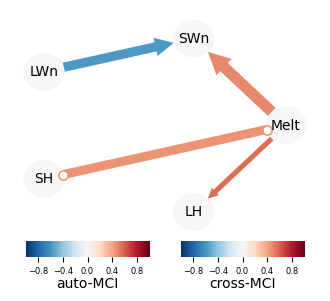

In [58]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/2061_2100/ICE/'
#plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2071_2100_majority_nofdrc_robustparcorr_rmmontrend_nostd_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

##### without seasonal cycle, max_lag=12, pc_alpha=0.05, divided by std

In [59]:
# Define variables and maximum lag
variables = ['Melt', 'SWn', 'LWn', 'SH', 'LH']
num_vars = len(variables)
max_lag = 12
pc_alpha = 0.05
remove_seasonal_cycle = True
detrend_by_month = True
divide_by_std = True
smooth_width_years = 15

# Initialize storage
link_types_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}
link_strengths_by_lag = {lag: defaultdict(list) for lag in range(0, max_lag + 1)}

# For auto-MCI: store max self-MCI value and significance across ensemble members
node_self_mci_values = defaultdict(list)       # Max auto-MCI values
node_self_mci_significance = defaultdict(list) # Whether max auto-MCI is significant

for n in range(1, 51):  # Loop over 50 ensemble members
    # Load and prepare data
    int_vars = xr.open_dataset(file).sel(ensemble=n).sel(time=slice('2061-01-01','2100-12-31'))
    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=remove_seasonal_cycle, add_mask=True, mask_period=[5, 6, 7], detrend_by_month=detrend_by_month, divide_by_std=divide_by_std, smooth_width_years=smooth_width_years)
    results = pcmci.run_pcmciplus(tau_min=0, tau_max=max_lag, pc_alpha=pc_alpha, contemp_collider_rule='conservative')

    graph = results['graph']
    val_matrix = results['val_matrix']

    # Collect cross-links
    for lag in range(0, max_lag + 1):
        for i in range(num_vars):
            for j in range(num_vars):
                if i != j:
                    link_type = graph[i, j, lag]
                    link_strength = val_matrix[i, j, lag]

                    link_types_by_lag[lag][(i, j)].append(link_type)
                    link_strengths_by_lag[lag][(i, j)].append(link_strength)

    # Compute max auto-MCI (across all lags ≥1) and check significance
    for i, var in enumerate(variables):
        # Extract all self-lag values
        self_vals = val_matrix[i, i, 1:]
        max_val = np.max(np.abs(self_vals))   # Max magnitude auto-MCI
        max_lag_idx = np.argmax(np.abs(self_vals)) + 1  # Which lag

        # Check significance: is there a self-link at that lag in the graph?
        is_significant = graph[i, i, max_lag_idx] != '' and graph[i, i, max_lag_idx] != 'o-o'

        node_self_mci_values[var].append(max_val)
        node_self_mci_significance[var].append(is_significant)

In [60]:
# Summarize cross-links as before
summary_links_by_lag = {lag: {} for lag in range(0, max_lag + 1)}

for lag in range(0, max_lag + 1):
    for (i, j), types in link_types_by_lag[lag].items():
        freq_link_type, freq_count = Counter(types).most_common(1)[0]

        if freq_link_type == '':
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': None,
                'frequency': freq_count
            }
        else:
            avg_strength = np.mean([s for t, s in zip(types, link_strengths_by_lag[lag][(i, j)]) if t == freq_link_type])
            summary_links_by_lag[lag][(i, j)] = {
                'link_type': freq_link_type,
                'avg_strength': avg_strength,
                'frequency': freq_count
            }

# Compute node colors: average max auto-MCI, but set to 0 if not significant in majority of members
summary_nodes = {}
for var in variables:
    # Fraction of members where max auto-MCI is significant
    sig_fraction = np.mean(node_self_mci_significance[var])

    if sig_fraction > 0.5:  # majority significant
        summary_nodes[var] = np.mean(node_self_mci_values[var])
    else:
        summary_nodes[var] = 0.0

In [61]:
# Prepare matrices for cross-links
link_types = np.full((num_vars, num_vars, max_lag + 1), '', dtype='U3')
link_colors = np.zeros((num_vars, num_vars, max_lag + 1))
link_widths = np.zeros((num_vars, num_vars, max_lag + 1))

for lag in range(0, max_lag + 1):
    for (i, j), link_info in summary_links_by_lag[lag].items():
        link_type = link_info['link_type']
        avg_strength = link_info['avg_strength']
        frequency = link_info['frequency']

        if link_type != '' and avg_strength is not None:
            link_types[i, j, lag] = link_type
            link_colors[i, j, lag] = avg_strength
            link_widths[i, j, lag] = frequency

# Node colors: summary_nodes already considers significance
node_colors = [summary_nodes[var] for var in variables]

# Assign node colors to self-link at lag 1 (for plotting)
for i in range(num_vars):
    link_colors[i, i, 1] = node_colors[i]
    link_types[i, i, 1] = '-->'

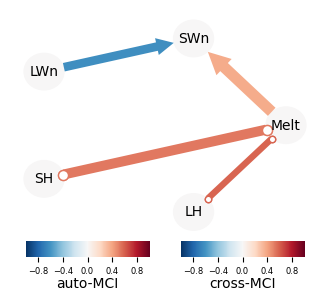

In [62]:
## Plot the summary causal graph

# Plot the summary causal graph with tp.plot_graph
tp.plot_graph(
    val_matrix=link_colors,  # Use the color matrix across all lags, including lag=0
    graph=link_types,  # Use the most frequent link type for each lag, including lag=0
    var_names=variables,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    link_width=link_widths,  # Use the width matrix across all lags, including lag=0
    node_size=0.4,
    figsize=(4, 3),
    #lagged_links=True  # This setting allows multiple links for different lags to be displayed
);

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/CESM2_F09/LENS2/2061_2100/ICE/'
#plt.savefig(plot_dir+'graph_summary_mostfreq_pcmciplus_melt_SEB_noGHF_F09BSSP370_realJJA_GrIS_ablation_ICEall_noseasonality_LENS2_2071_2100_majority_nofdrc_robustparcorr_rmmontrend_nostd_taumax'+str(max_lag)+'_alpha'+str(pc_alpha)+'_sig.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)